In [1]:
#testing the ODEsolving etc.

In [1]:
import scipy
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import pyplot as plt
import itertools
import time

In [2]:
all_df = pd.read_csv('GSE124821_data_1e8.csv')
KPB25L_df = all_df[all_df['Cell_Line']=="KPB25L"]

In [3]:
KPB25L_df 

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
0,SRX5100689,0.002064,0.000734,0.000382,0.000513,antiPD1; antiCTLA4;,day7,day7,GSM3554691,KPB25L
1,SRX5100686,0.003045,0.001085,0.000000,0.000323,no_treatment,day7,day7,GSM3554692,KPB25L
2,SRX5100687,0.003010,0.001099,0.000035,0.000405,no_treatment,day7,day7,GSM3554693,KPB25L
3,SRX5100692,0.003047,0.001047,0.000033,0.000403,no_treatment,day7,day7,GSM3554694,KPB25L
4,SRX5100693,0.003165,0.000861,0.000000,0.000336,no_treatment,day7,day7,GSM3554695,KPB25L
5,SRX5100690,0.002253,0.000725,0.000024,0.000245,antiPD1; antiCTLA4;,day7,day7,GSM3554696,KPB25L
6,SRX5100691,0.003449,0.000867,0.000003,0.000401,antiPD1; antiCTLA4;,day7,day7,GSM3554697,KPB25L
7,SRX5100680,0.004349,0.000949,0.000017,0.000510,antiPD1; antiCTLA4;,day7,day7,GSM3554698,KPB25L
8,SRX5100597,0.002915,0.000706,0.000000,0.000280,no_treatment,end,end,GSM3554699,KPB25L
9,SRX5100596,0.003232,0.001002,0.000000,0.000360,no_treatment,day3,day3,GSM3554700,KPB25L



Number of replicates 14
Dendritic_quanTIseq    0.003003
NK_quanTIseq           0.000704
T.CD8_quanTIseq        0.000144
Tregs_quanTIseq        0.000420
dtype: float64
<class 'pandas.Series'>
0.004271564290571428

Number of replicates 8
Dendritic_quanTIseq    0.003355
NK_quanTIseq           0.000979
T.CD8_quanTIseq        0.000107
Tregs_quanTIseq        0.000474
dtype: float64
<class 'pandas.Series'>
0.004913895825

Number of replicates 12
Dendritic_quanTIseq    0.002554
NK_quanTIseq           0.000620
T.CD8_quanTIseq        0.000006
Tregs_quanTIseq        0.000263
dtype: float64
<class 'pandas.Series'>
0.0034417617406666662

Number of replicates 9
Dendritic_quanTIseq    0.002960
NK_quanTIseq           0.000698
T.CD8_quanTIseq        0.000224
Tregs_quanTIseq        0.000435
dtype: float64
<class 'pandas.Series'>
0.0043164094386666674

Number of replicates 4
Dendritic_quanTIseq    0.003643
NK_quanTIseq           0.000934
T.CD8_quanTIseq        0.000196
Tregs_quanTIseq        0.000581
dt

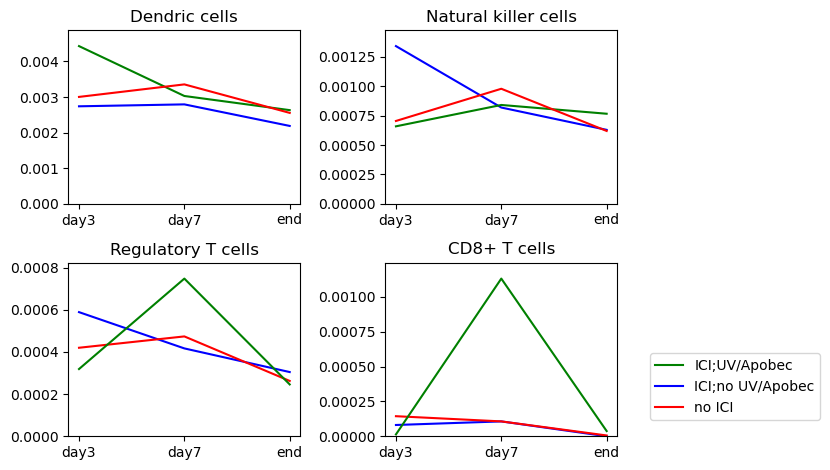

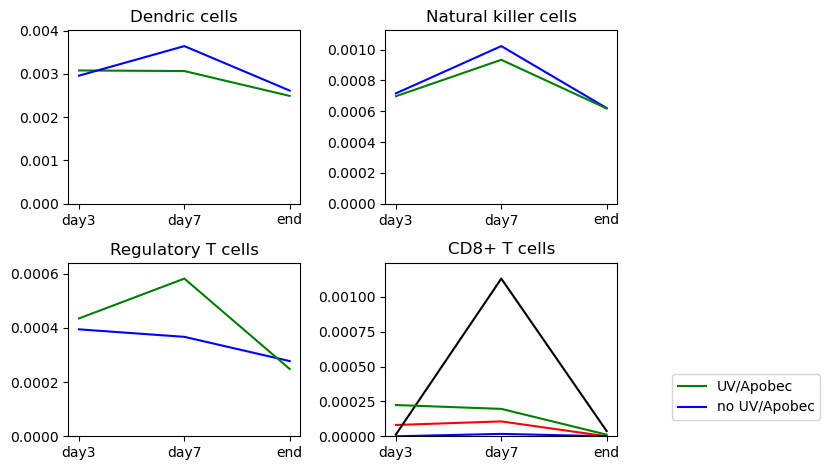

In [4]:


treatment_df = KPB25L_df[KPB25L_df['Mouse_treatment']!="no_treatment"]
no_treatment_df = KPB25L_df[KPB25L_df['Mouse_treatment']=="no_treatment"]

quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]

time_points = ["day3","day7","end"]

# no treatment (mutagen and no mutagen together)
no_treatment_Ds = []
no_treatment_NKs = []
no_treatment_T8s = []
no_treatment_Tregs = []

scatter_no_treatment_Ds = []
scatter_no_treatment_NKs = []
scatter_no_treatment_Tregs = []
scatter_no_treatment_T8s = []
scatter_no_treatment_times = []
for day in time_points:
    day_df = no_treatment_df[no_treatment_df['Condition'].str.contains(day)]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    no_treatment_Ds.append(averages["Dendritic_quanTIseq"])
    no_treatment_NKs.append(averages["NK_quanTIseq"])
    no_treatment_T8s.append(averages["T.CD8_quanTIseq"])
    no_treatment_Tregs.append(averages["Tregs_quanTIseq"])
    no_treatment_total = sum(averages)
    print(no_treatment_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_no_treatment_Ds.append(i)
                scatter_no_treatment_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_no_treatment_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_no_treatment_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_no_treatment_T8s.append(i)
no_treatment_mutagen_Ds = []
no_treatment_mutagen_NKs = []
no_treatment_mutagen_T8s = []
no_treatment_mutagen_Tregs = []

scatter_no_treatment_mutagen_Ds = []
scatter_no_treatment_mutagen_NKs = []
scatter_no_treatment_mutagen_Tregs = []
scatter_no_treatment_mutagen_T8s = []
scatter_no_treatment_mutagen_times = []
for day in time_points:
    day_df = no_treatment_df[no_treatment_df['Condition'].str.contains("_"+day)]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    no_treatment_mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    no_treatment_mutagen_NKs.append(averages["NK_quanTIseq"])
    no_treatment_mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    no_treatment_mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    no_treatment_mutagen_total = sum(averages)
    print(no_treatment_mutagen_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_no_treatment_mutagen_Ds.append(i)
                scatter_no_treatment_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_no_treatment_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_no_treatment_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_no_treatment_mutagen_T8s.append(i)


no_treatment_no_mutagen_Ds = []
no_treatment_no_mutagen_NKs = []
no_treatment_no_mutagen_T8s = []
no_treatment_no_mutagen_Tregs = []

scatter_no_treatment_no_mutagen_Ds = []
scatter_no_treatment_no_mutagen_NKs = []
scatter_no_treatment_no_mutagen_Tregs = []
scatter_no_treatment_no_mutagen_T8s = []
scatter_no_treatment_no_mutagen_times = []
for day in time_points:
    day_df = no_treatment_df[no_treatment_df['Condition']==day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    no_treatment_no_mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    no_treatment_no_mutagen_NKs.append(averages["NK_quanTIseq"])
    no_treatment_no_mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    no_treatment_no_mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    no_treatment_no_mutagen_total = sum(averages)
    print(no_treatment_no_mutagen_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_no_treatment_no_mutagen_Ds.append(i)
                scatter_no_treatment_no_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_no_treatment_no_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_no_treatment_no_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_no_treatment_no_mutagen_T8s.append(i)
#treatment with mutagen
mutagen_Ds = []
mutagen_NKs = []
mutagen_T8s = []
mutagen_Tregs = []

scatter_mutagen_Ds = []
scatter_mutagen_NKs = []
scatter_mutagen_Tregs = []
scatter_mutagen_T8s = []
scatter_mutagen_times = []
for day in time_points:
    day_df = treatment_df[treatment_df['Condition'].str.contains('_'+day)]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    mutagen_NKs.append(averages["NK_quanTIseq"])
    mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    mutagen_total = sum(averages)
    print(mutagen_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_mutagen_Ds.append(i)
                scatter_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_mutagen_T8s.append(i)


#treatment with mutagen
no_mutagen_Ds = []
no_mutagen_NKs = []
no_mutagen_T8s = []
no_mutagen_Tregs = []
scatter_no_mutagen_Ds = []
scatter_no_mutagen_NKs = []
scatter_no_mutagen_Tregs = []
scatter_no_mutagen_T8s = []
scatter_no_mutagen_times = []

for day in time_points:
    day_df = treatment_df[treatment_df['Condition']==day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    
    print(averages)
    stds = day_df.filter(items=quanTIseq_cols).std()
    
    # print(averages+stds)
    # print(averages-stds)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    no_mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    no_mutagen_NKs.append(averages["NK_quanTIseq"])
    no_mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    no_mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    no_mutagen_total = sum(averages)
    print(no_mutagen_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_no_mutagen_Ds.append(i)
                scatter_no_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_no_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_no_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_no_mutagen_T8s.append(i)


fig,ax = plt.subplots(2,2)

Dplot = ax[0,0]
Dplot.plot(time_points,no_mutagen_Ds,'g',label='ICI;UV/Apobec')
Dplot.plot(time_points,mutagen_Ds,'b',label='ICI;no UV/Apobec')

Dplot.plot(time_points,no_treatment_Ds,'r',label='no ICI')
Dplot.set_title('Dendric cells')
Dplot.set_ylim(0.0,max([*no_mutagen_Ds,*mutagen_Ds,*no_treatment_Ds])*1.1)
handles,labels = Dplot.get_legend_handles_labels()
NKplot = ax[0,1]
NKplot.plot(time_points,no_mutagen_NKs,'b')
NKplot.plot(time_points,mutagen_NKs,'g')
NKplot.plot(time_points,no_treatment_NKs,'r')
NKplot.set_title('Natural killer cells')

NKplot.set_ylim(0.0,max([*no_mutagen_NKs,*mutagen_NKs,*no_treatment_NKs])*1.1)

Tregplot = ax[1,0]
Tregplot.plot(time_points,no_mutagen_Tregs,'b')
Tregplot.plot(time_points,no_treatment_Tregs,'r')
Tregplot.plot(time_points,mutagen_Tregs,'g')

Tregplot.set_title('Regulatory T cells')
Tregplot.set_ylim(0.0,max([*no_mutagen_Tregs,*mutagen_Tregs,*no_treatment_Tregs])*1.1)

T8plot = ax[1,1]
T8plot.plot(time_points,no_mutagen_T8s,'b')
T8plot.plot(time_points,no_treatment_T8s,'r')
T8plot.plot(time_points,mutagen_T8s,'g')

T8plot.set_title('CD8+ T cells')
T8plot.set_ylim(0.0,max([*no_mutagen_T8s,*mutagen_T8s,*no_treatment_T8s])*1.1)

fig.legend(handles,labels,bbox_to_anchor=(0.3, 0.1,1,1),loc = 'lower right')
plt.tight_layout()
plt.show()

fig,ax = plt.subplots(2,2)

Dplot = ax[0,0]
Dplot.plot(time_points,no_treatment_no_mutagen_Ds,'g',label='UV/Apobec')
Dplot.plot(time_points,no_treatment_mutagen_Ds,'b',label='no UV/Apobec')

Dplot.set_title('Dendric cells')
Dplot.set_ylim(0.0,max([*no_treatment_no_mutagen_Ds,*no_treatment_mutagen_Ds])*1.1)
handles,labels = Dplot.get_legend_handles_labels()
NKplot = ax[0,1]
NKplot.plot(time_points,no_treatment_no_mutagen_NKs,'b')
NKplot.plot(time_points,no_treatment_mutagen_NKs,'g')

NKplot.set_title('Natural killer cells')

NKplot.set_ylim(0.0,max([*no_treatment_no_mutagen_NKs,*no_treatment_mutagen_NKs])*1.1)

Tregplot = ax[1,0]
Tregplot.plot(time_points,no_treatment_no_mutagen_Tregs,'b')
Tregplot.plot(time_points,no_treatment_mutagen_Tregs,'g')

Tregplot.set_title('Regulatory T cells')
Tregplot.set_ylim(0.0,max([*no_treatment_no_mutagen_Tregs,*no_treatment_mutagen_Tregs])*1.1)

T8plot = ax[1,1]
T8plot.plot(time_points,no_mutagen_T8s,'r')
T8plot.plot(time_points,mutagen_T8s,'k')
T8plot.plot(time_points,no_treatment_no_mutagen_T8s,'b')
T8plot.plot(time_points,no_treatment_mutagen_T8s,'g')

T8plot.set_title('CD8+ T cells')
T8plot.set_ylim(0.0,max([*no_treatment_no_mutagen_T8s,*no_treatment_mutagen_T8s,*mutagen_T8s,*no_mutagen_T8s])*1.1)

fig.legend(handles,labels,bbox_to_anchor=(0.3, 0.1,1,1),loc = 'lower right')
plt.tight_layout()
plt.show()

In [5]:
import math

In [6]:
def cancer_ode(t,y,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC_comb,
               K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr_comb,d_T8,
              lambda_T8_comb,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC_comb*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr_comb*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8_comb*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))
def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    ) 
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
params = {'lambda_C':1.5,
          'C_M':0.8,
          'eta_8':328.25,
          'eta_N':300,
          'd_C':0.17,#0.17,
          'lambda_DC_comb':8e-5,
          # 'D_0':2e-5,
          'K_C':0.4,
          'd_D':0.1,
          'sigma_N':5e-5,
          'd_N':0.1,
          'gamma_N':150,
          'a_C':0.5,
          'beta_1':0.4,
          'beta_2':2e-4,
          'd_Tr':0.2,
          'lambda_Tr_comb':2e-4,
          'd_T8':0.18,
          'lambda_T8_comb':1.08e-3,
          'K_Tr':2.5e-4,
          'K_D':4e-4,
          'C_init':0.8,
          'D_init':0.0,
          'N_init':0.0,
          'Tr_init':0.0,
          'T8_init':0.0}
          

lambda_C   = params['lambda_C']
C_M        = params['C_M']
eta_8      = params['eta_8']
eta_N      = params['eta_N']
d_C            = params['d_C']
lambda_DC_comb = params['lambda_DC_comb']
# D_0            = params['D_0']
K_C        = params['K_C']
d_D        = params['d_D']
sigma_N    = params['sigma_N']
d_N        = params['d_N']
gamma_N    = params['gamma_N']
a_C        = params['a_C']
beta_1     = params['beta_1']
beta_2     = params['beta_2']
d_Tr       = params['d_Tr']
lambda_Tr_comb  = params['lambda_Tr_comb']
# Tr_0       = params['Tr_0']
d_T8       = params['d_T8']
lambda_T8_comb  = params['lambda_T8_comb']
# T8_0       = params['T8_0']
K_Tr       = params['K_Tr']
K_D        = params['K_D']


C_init     = params['C_init']
D_init     = params['D_init']
N_init     = params['N_init']
Tr_init    = params['Tr_init']
T8_init    = params['T8_init']
# eta_N = 300
# eta_8 = 328.2
# lambda_C = 1*lambda_C
# d_Tr = 1*d_Tr
# sigma_N = 2*sigma_N
# lambda_Tr = 2*lambda_Tr
# lamba_T8 = 2*lambda_T8
orig_params = params


def mean_square_error(y):
    error = 0
    if 'C' in objective_function_day3.keys():
        N = 2*5
        
        error+=(y[0,0]-objective_function_day3['C'])**2
        error+=(y[0,1]-objective_function_day7['C'])**2
    else:
        N = 2*4
    error+=(y[1,0]-objective_function_day3['Ds'])**2
    error+=(y[1,1]-objective_function_day7['Ds'])**2
    error+=(y[2,0]-objective_function_day3['NKs'])**2
    error+=(y[2,1]-objective_function_day7['NKs'])**2
    error+=(y[3,0]-objective_function_day3['Tregs'])**2
    error+=(y[3,1]-objective_function_day7['Tregs'])**2
    error+=(y[4,0]-objective_function_day3['T8s'])**2
    error+=(y[4,1]-objective_function_day7['T8s'])**2
    return math.sqrt(error/N)

def mean_square_error_rel(y):
    error = 0
    if 'C' in objective_function_day3.keys():
        N = 2*5 
        
        error+=((y[0,0]-objective_function_day3['C'])/y[0,0])**2
        error+=((y[0,1]-objective_function_day7['C'])/y[1,0])**2
    else:
        N = 2*4
    error+=((y[1,0]-objective_function_day3['Ds'])/y[1,0])**2
    error+=((y[1,1]-objective_function_day7['Ds'])/y[1,1])**2
    error+=((y[2,0]-objective_function_day3['NKs'])/y[2,0])**2
    error+=((y[2,1]-objective_function_day7['NKs'])/y[2,1])**2
    error+=((y[3,0]-objective_function_day3['Tregs'])/y[3,0])**2
    error+=((y[3,1]-objective_function_day7['Tregs'])/y[3,1])**2
    error+=((y[4,0]-objective_function_day3['T8s'])/y[4,0])**2
    error+=((y[4,1]-objective_function_day7['T8s'])/y[4,1])**2
    return math.sqrt(error/N)

def mean_square_error_rel(pred, true):
    return np.sqrt(np.mean(np.square(np.divide((pred - true-1e-9),(pred)))))
def max_error_rel(pred, true):
    return np.sqrt(np.max(np.absolute(np.divide((pred - true-1e-9),(pred)))))

In [15]:
# fitting UV treatment

In [16]:
objective_function_day3 = {'Ds':mutagen_Ds[0],
                          'NKs':mutagen_NKs[0],
                          'Tregs':mutagen_Tregs[0],
                          'T8s':mutagen_T8s[0]}
objective_function_day7 = {'Ds':mutagen_Ds[1],
                          'NKs':mutagen_NKs[1],
                          'Tregs':mutagen_Tregs[1],
                          'T8s':mutagen_T8s[1]}

true_mutagen = np.array([mutagen_Ds[:2],mutagen_NKs[:2],mutagen_Tregs[:2],mutagen_T8s[:2]])

In [17]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[2e-5],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25,0.4,0.5,0.6,0.7,1.0],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5,1.0,2.0]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3,5e-4],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,4e-4,5e-4,1e-3],'d_D':[0.01,0.1,1.0],'K_Tr': [2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3,5e-4],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,4e-4,5e-4,1e-3],'d_D':[0.01,0.1,1.0],'K_Tr': [2.25e-5,3e-5,4e-5,5e-5,1e-4,1e-3],'d_N':[0.1,0.11,0.13,0.15,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[0.0001,0.0005,0.001,0.002],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,4e-4,5e-4,1e-3],'d_D':[0.01,0.1,1.0],'K_Tr': [2.25e-5,3e-5,4e-5,5e-5,1e-4,1e-3,5e-3,1e-2],'d_N':[0.1,0.11,0.13,0.15,0.17,0.175,0.18,0.2,0.22,0.5]}
#initial parameter screen
params_to_change = {'lambda_T8_comb':[1e-5,5e-4,1e-4,5e-4,1e-3],'lambda_DC_comb':[0.0001,0.0005,0.001,0.002],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[1e-5,5e-5,1e-4,5e-4,1e-3],'d_D':[0.01,0.1,1.0],'K_Tr': [2.25e-5,3e-5,4e-5,5e-5,1e-4,1e-3,5e-3,1e-2],'d_N':[0.1,0.13,0.15,0.175,0.2,0.5]}
#narrowing down
params_to_change = {'lambda_T8_comb':[1e-5,3e-4,5e-4,1e-4,5e-4,1e-3],'lambda_DC_comb':[0.0001,0.0005,0.001,0.002],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[1e-5,5e-5,1e-4,5e-4,1e-3],'d_D':[0.01,0.1,1.0],'K_Tr': [2.25e-5,3e-5,4e-5,5e-5,1e-4,1e-3,5e-3,1e-2],'d_N':[0.1,0.13,0.15,0.175,0.2,0.5]}
# {'lambda_T8_comb': 0.0005, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.18, 'sigma_N': 0.0005, 'd_D': 0.1, 'K_Tr': 0.001, 'd_N': 0.5}
params_to_change = {'lambda_T8_comb':[1e-5,3e-4,5e-4,1e-4,2e-4,5e-4,1e-3],'lambda_DC_comb':[0.0001,0.0005,0.001,0.002,0.005,0.01],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,7e-4,1e-3],'d_T8': [0.01,0.075,0.1,0.18,0.2,0.25,0.5],'sigma_N':[5e-5,1e-4,2e-4,5e-4,7e-4,1e-3],'d_D':[0.01,0.05,0.1,0.2,1.0],'K_Tr': [2.25e-5,5e-5,1e-4,1e-3,5e-3,1e-2],'d_N':[0.1,0.15,0.175,0.2,0.5,0.75,1.0]}
# {'lambda_T8_comb': 0.0005, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.18, 'sigma_N': 0.0005, 'd_D': 0.1, 'K_Tr': 0.001, 'd_N': 0.5}
# {'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.1, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.005, 'd_N': 0.5} 0.37 error
# {'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.01, 'd_N': 0.5} 0.366 error
params = orig_params.copy()

/home/participant/miniforge3/envs/mibproject/lib/python3.11/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `abstol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


mean square rel error is 201.90018363080077
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0001, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 2.25e-05, 'd_N': 0.1}
minimum maximum rel error is 23.88808884547103
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0001, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 2.25e-05, 'd_N': 0.1}
mean square rel error is 102.9982612383548
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0001, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 5e-05, 'd_N': 0.1}
minimum maximum rel error is 17.053122134699734
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0001, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 5e-05, 'd_N': 0.1}
mean square rel error is 61.70304151785713
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0001, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.0001, 'd_N': 0.1}
minimum maxim

/home/participant/miniforge3/envs/mibproject/lib/python3.11/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `abs_tol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


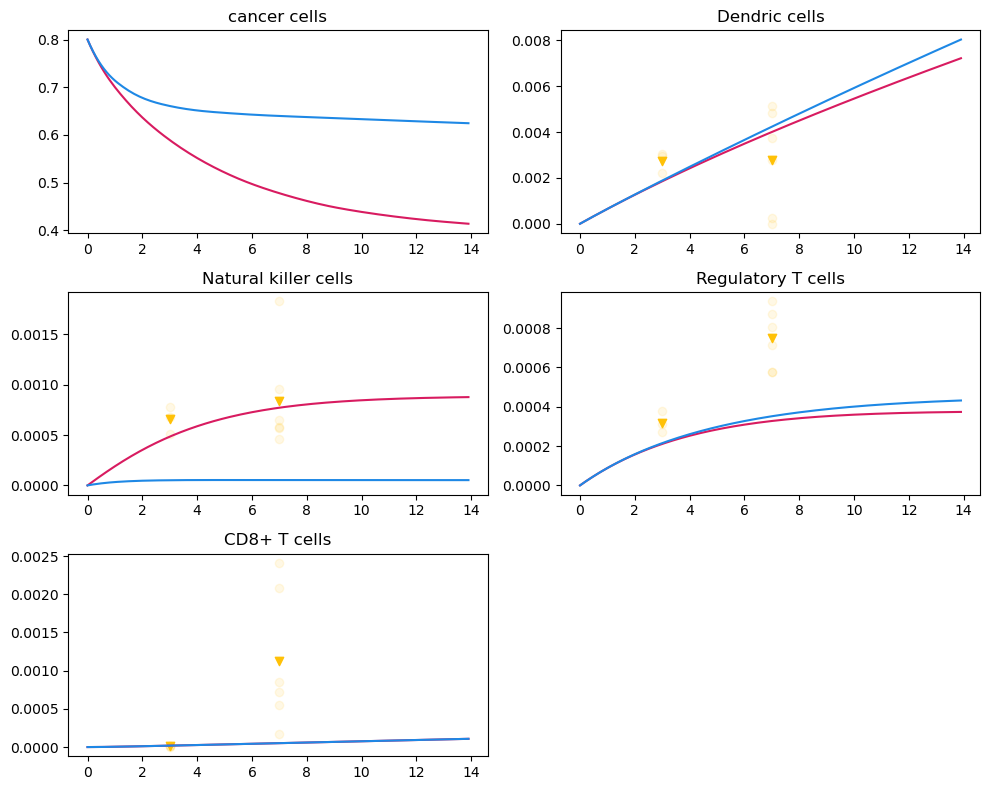

iteration 155580 of 2593080 i.e. 5.9998148919431715%
time : 236.6033775806427, time per iteration : 0.0015207827328746798
iteration 181510 of 2593080 i.e. 6.999784040600367%
time : 277.72345089912415, time per iteration : 0.0015300724527525984
mean square rel error is 6.993709095989834
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.005, 'd_N': 0.1}
minimum maximum rel error is 4.395216192903889
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.005, 'd_N': 0.1}
mean square rel error is 6.839540551547226
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.01, 'd_N': 0.1}
minimum maximum rel error is 4.3440751518631755
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_

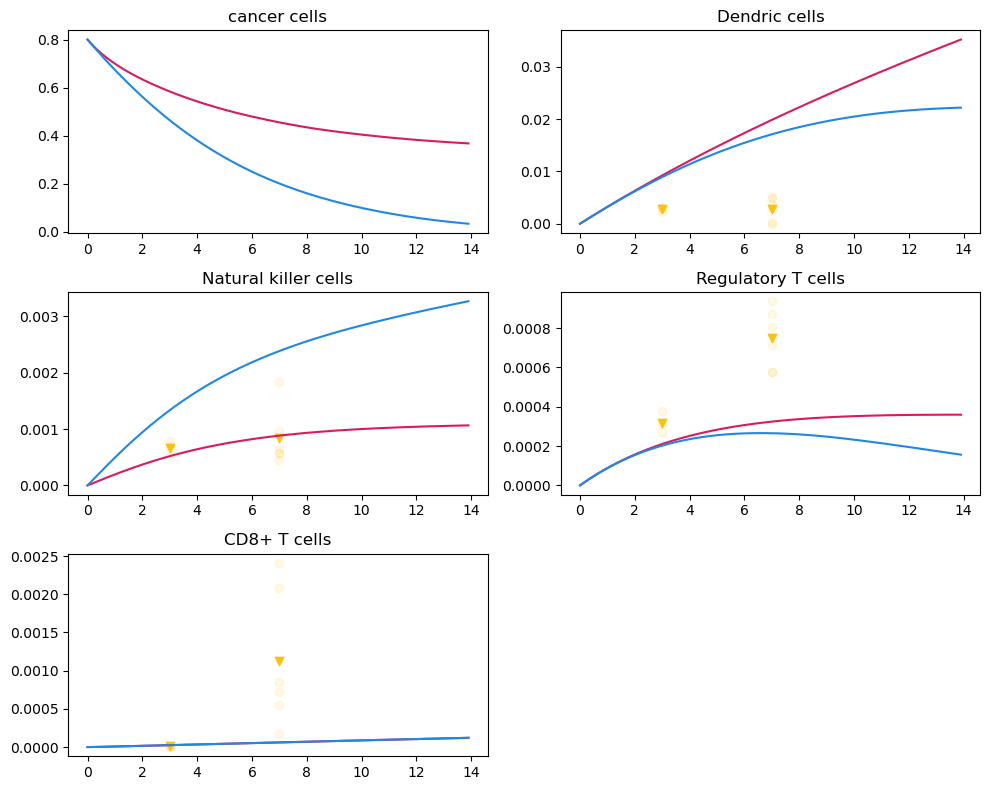

iteration 285230 of 2593080 i.e. 10.999660635229148%
time : 440.16251015663147, time per iteration : 0.0015431844832473143
minimum maximum rel error is 4.148020096985492
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.01, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.005, 'd_N': 0.1}
mean square rel error is 6.146597239153319
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.01, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.01, 'd_N': 0.1}
minimum maximum rel error is 4.101304621262335
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.01, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 0.01, 'd_N': 0.1}
mean square rel error is 6.137601998922149
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.01, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 0.0001, 'd_D': 0.01, 'K_Tr': 0.005, 'd_N': 0.1}
mean square rel error is 6.004291791242866
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.01, 'lambda_T

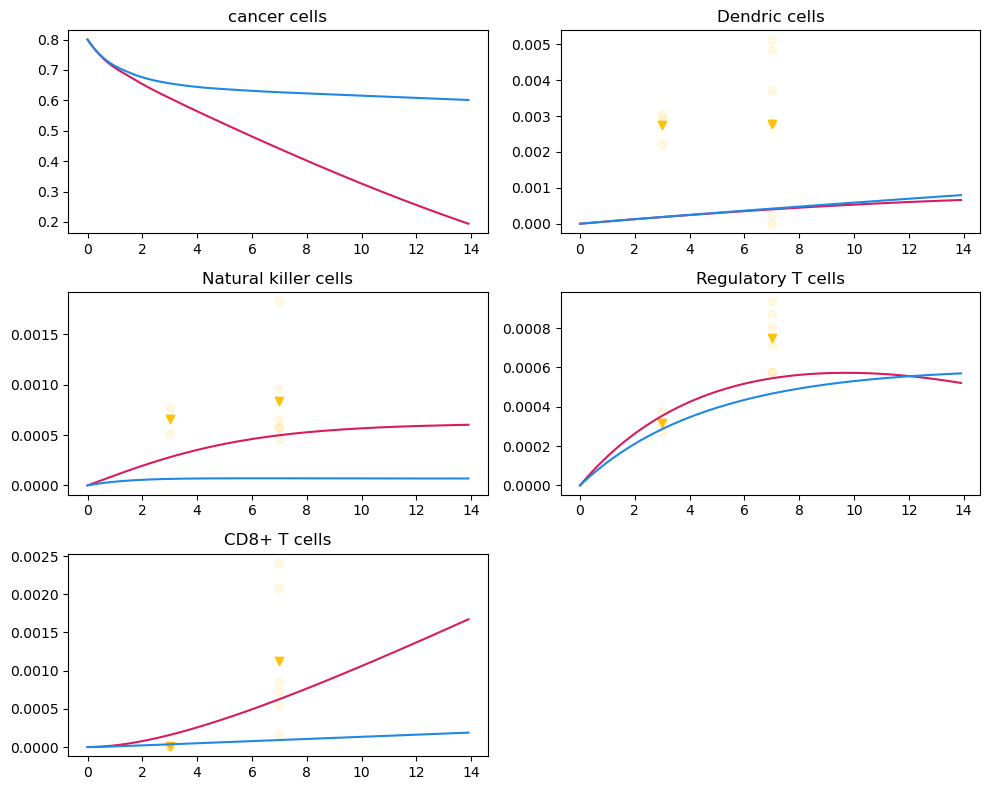

mean square rel error is 5.332366174872248
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.0001, 'lambda_Tr_comb': 0.000275, 'd_T8': 0.01, 'sigma_N': 0.0001, 'd_D': 0.01, 'K_Tr': 0.01, 'd_N': 0.1}
iteration 414880 of 2593080 i.e. 15.999506378515123%
time : 644.5775928497314, time per iteration : 0.0015536482666065644
mean square rel error is 3.093964778950687
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 2.25e-05, 'd_N': 0.1}
minimum maximum rel error is 2.718008889964642
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 2.25e-05, 'd_N': 0.1}
mean square rel error is 2.049966552278806
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'd_T8': 0.01, 'sigma_N': 5e-05, 'd_D': 0.01, 'K_Tr': 5e-05, 'd_N': 0.1}
minimum maximum rel error is 1.8734105435032666
{'lambda_T8_comb': 0.0003, 'lambda_DC_c

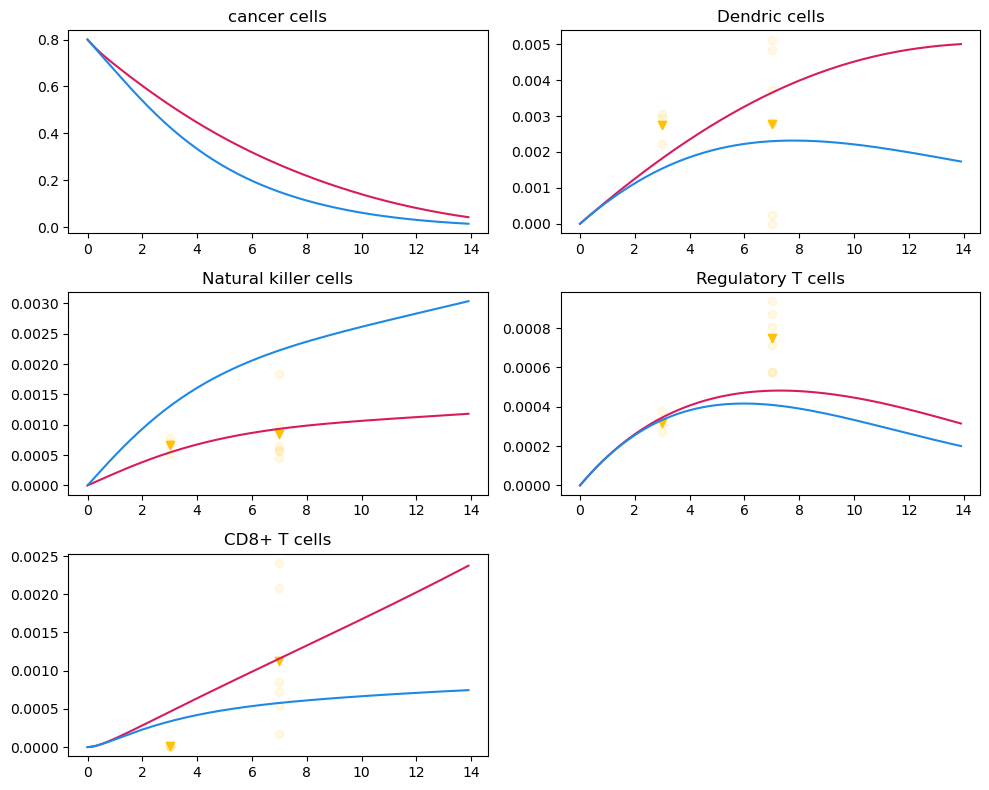

minimum maximum rel error is 0.9798511988359213
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.001, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.25, 'sigma_N': 0.001, 'd_D': 0.1, 'K_Tr': 0.001, 'd_N': 0.5}
mean square rel error is 0.4326842243453854
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.001, 'lambda_Tr_comb': 0.000275, 'd_T8': 0.01, 'sigma_N': 0.0002, 'd_D': 0.01, 'K_Tr': 0.001, 'd_N': 0.1}
minimum maximum rel error is 0.979740785401624
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.001, 'lambda_Tr_comb': 0.000275, 'd_T8': 0.25, 'sigma_N': 0.0007, 'd_D': 0.05, 'K_Tr': 0.001, 'd_N': 0.15}
minimum maximum rel error is 0.9797403346603468
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.001, 'lambda_Tr_comb': 0.000275, 'd_T8': 0.25, 'sigma_N': 0.0007, 'd_D': 0.05, 'K_Tr': 0.001, 'd_N': 0.175}
minimum maximum rel error is 0.979739903430787
{'lambda_T8_comb': 0.0003, 'lambda_DC_comb': 0.001, 'lambda_Tr_comb': 0.000275, 'd_T8': 0.25, 'sigma_N': 0.0007, 'd_D': 0.05, 'K_Tr': 0.001, 'd_N': 0.2}
m

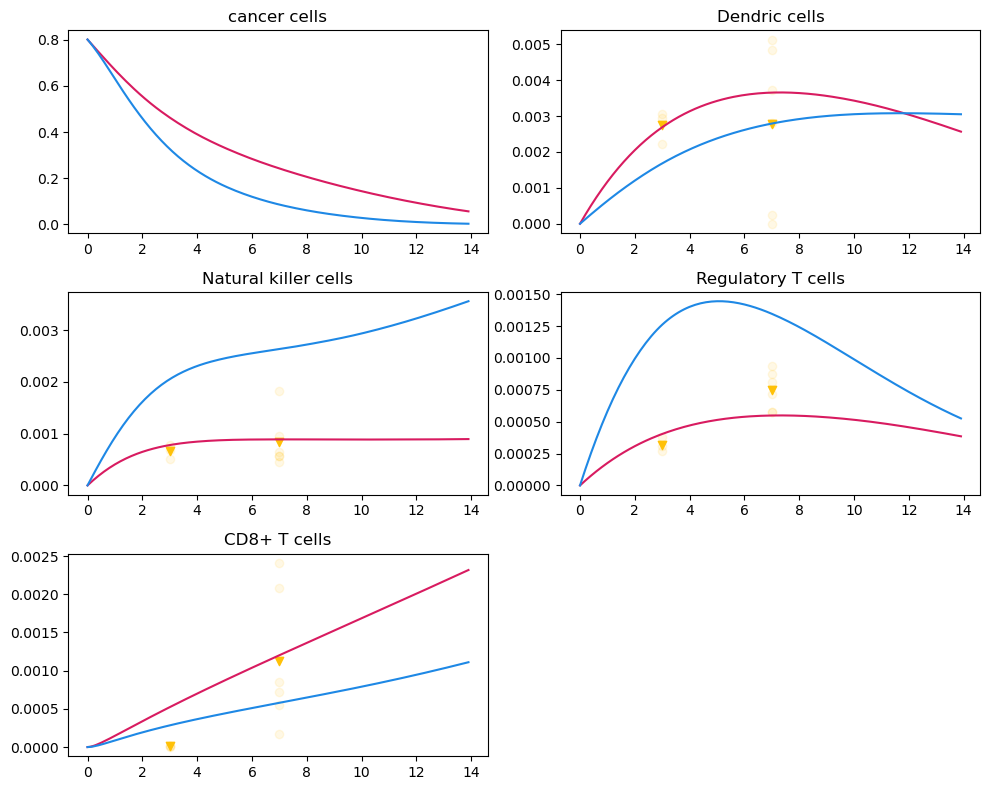

iteration 674180 of 2593080 i.e. 25.999197865087076%
time : 1071.465933084488, time per iteration : 0.0015892876280585125
iteration 700110 of 2593080 i.e. 26.999167013744273%
time : 1115.6529762744904, time per iteration : 0.0015935395527481259
iteration 726040 of 2593080 i.e. 27.999136162401467%
time : 1160.000638961792, time per iteration : 0.0015977089953195306
iteration 751970 of 2593080 i.e. 28.999105311058663%
time : 1203.4372057914734, time per iteration : 0.0016003792781513536
iteration 777900 of 2593080 i.e. 29.999074459715857%
time : 1244.6932797431946, time per iteration : 0.001600068491763973


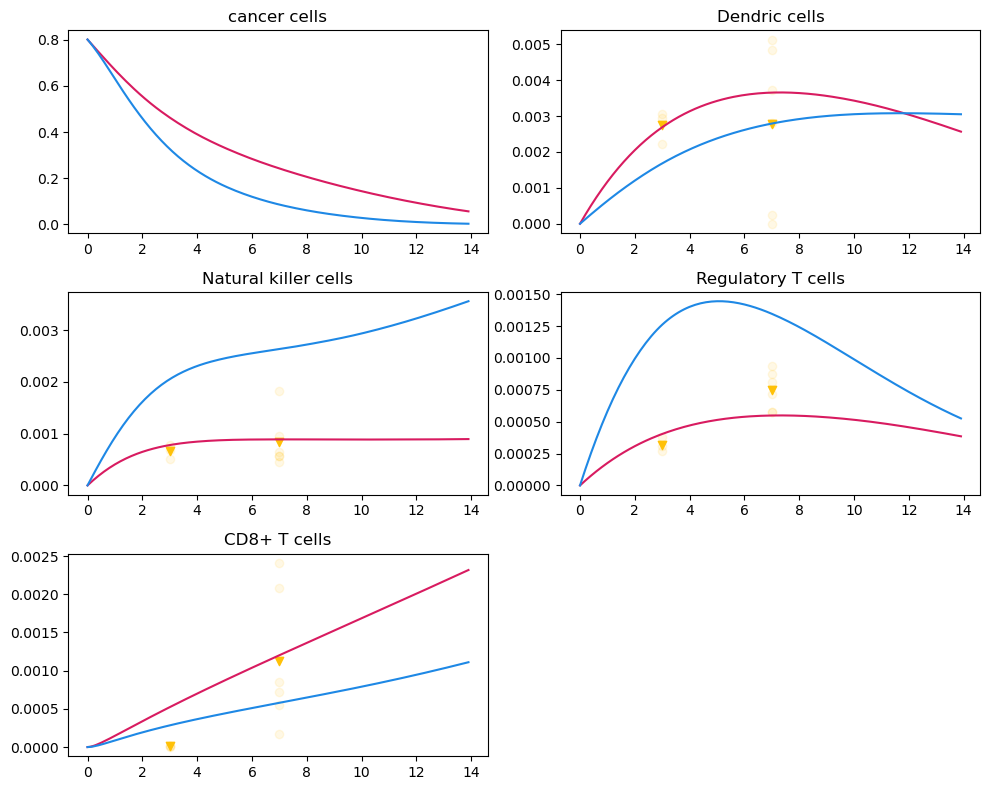

iteration 803830 of 2593080 i.e. 30.999043608373057%
time : 1288.4264430999756, time per iteration : 0.001602859364666628
iteration 829760 of 2593080 i.e. 31.999012757030247%
time : 1332.4874103069305, time per iteration : 0.0016058708666444883
iteration 855690 of 2593080 i.e. 32.998981905687444%
time : 1376.040870666504, time per iteration : 0.0016081067567302457
iteration 881620 of 2593080 i.e. 33.99895105434464%
time : 1420.2662250995636, time per iteration : 0.0016109732368816084
minimum maximum rel error is 0.9761354053825271
{'lambda_T8_comb': 0.0005, 'lambda_DC_comb': 0.001, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0007, 'd_D': 0.05, 'K_Tr': 0.0001, 'd_N': 0.1}
iteration 907550 of 2593080 i.e. 34.99892020300184%
time : 1464.6032583713531, time per iteration : 0.0016137989734685177


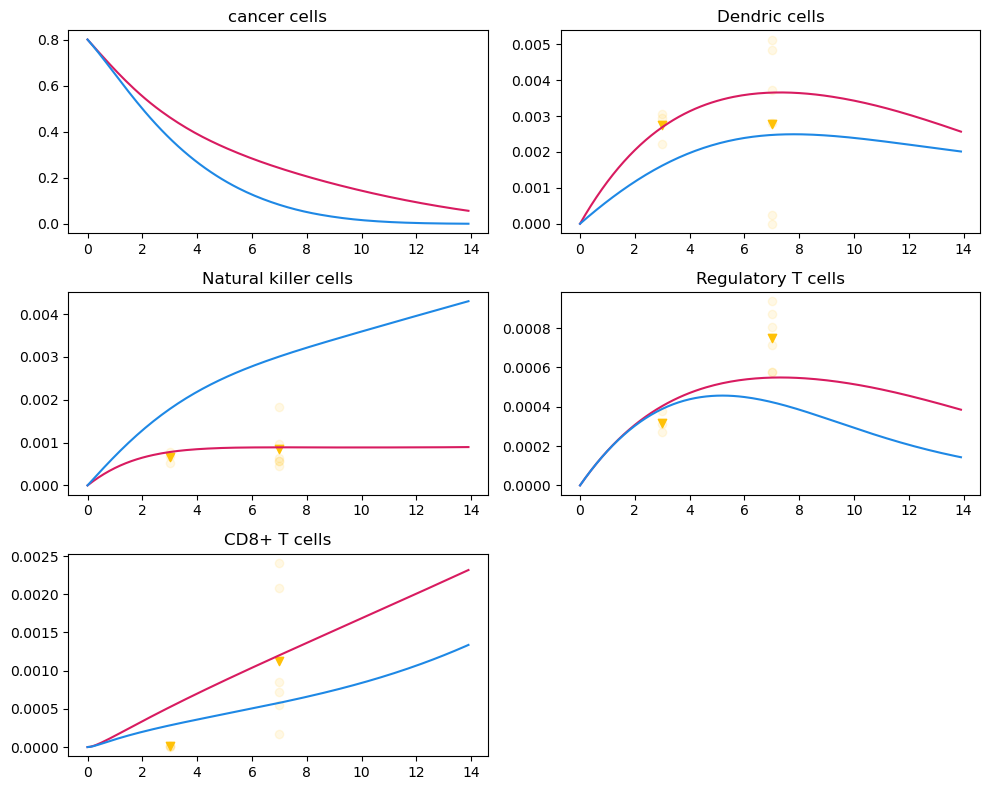

iteration 933480 of 2593080 i.e. 35.99888935165903%
time : 1509.8047502040863, time per iteration : 0.001617393784766772
iteration 959410 of 2593080 i.e. 36.99885850031623%
time : 1554.7782766819, time per iteration : 0.0016205566719983116
iteration 985340 of 2593080 i.e. 37.99882764897342%
time : 1599.8585333824158, time per iteration : 0.0016236614096478534
iteration 1011270 of 2593080 i.e. 38.99879679763062%
time : 1646.0260829925537, time per iteration : 0.001627682105661746
iteration 1037200 of 2593080 i.e. 39.99876594628781%
time : 1691.9448969364166, time per iteration : 0.0016312619523104672


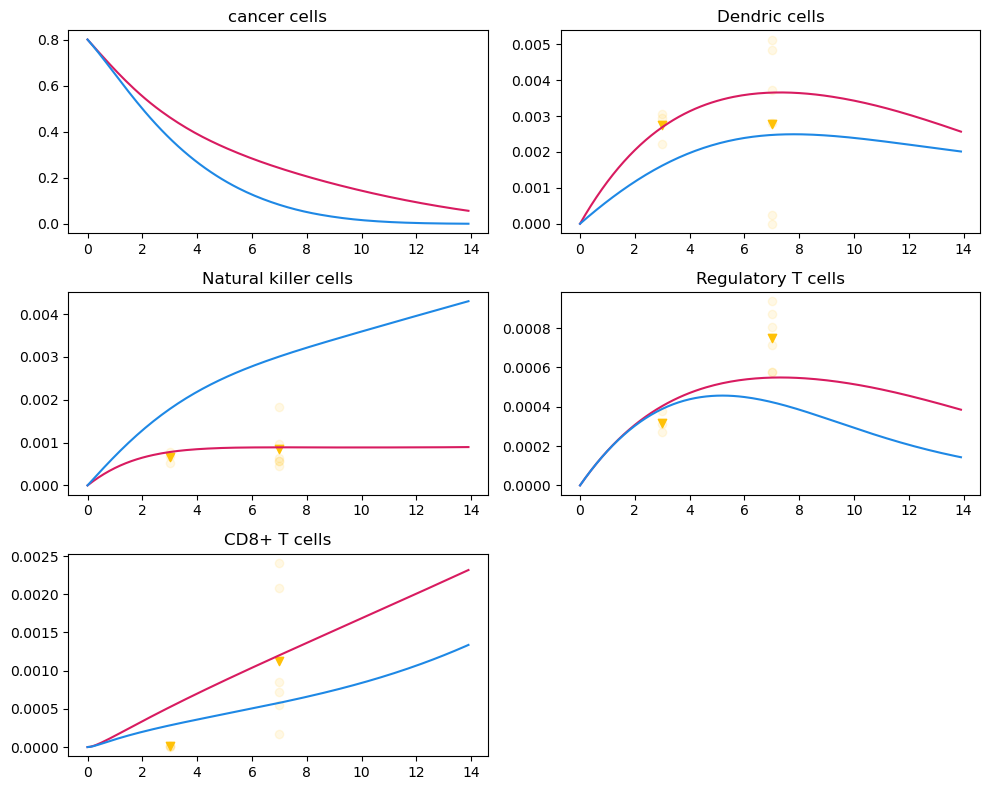

iteration 1063130 of 2593080 i.e. 40.99873509494501%
time : 1738.9021062850952, time per iteration : 0.0016356439064696652
iteration 1089060 of 2593080 i.e. 41.998704243602205%
time : 1785.6215634346008, time per iteration : 0.001639598886594495
iteration 1114990 of 2593080 i.e. 42.9986733922594%
time : 1830.6582686901093, time per iteration : 0.0016418607060961169
iteration 1140920 of 2593080 i.e. 43.99864254091659%
time : 1870.526822566986, time per iteration : 0.0016394899051353172
iteration 1166850 of 2593080 i.e. 44.998611689573785%
time : 1911.453863143921, time per iteration : 0.0016381316048711667


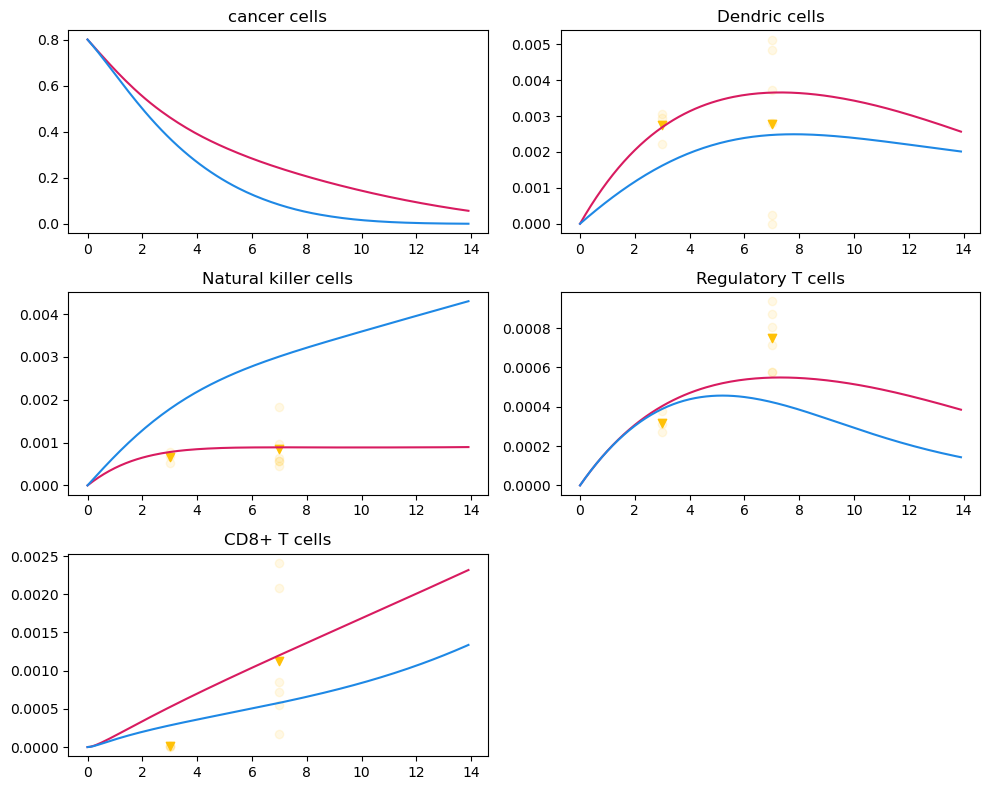

iteration 1192780 of 2593080 i.e. 45.998580838230986%
time : 1952.5214579105377, time per iteration : 0.0016369501986204813
iteration 1218710 of 2593080 i.e. 46.99854998688818%
time : 1992.9129815101624, time per iteration : 0.0016352643217091534
iteration 1244640 of 2593080 i.e. 47.99851913554537%
time : 2034.2239158153534, time per iteration : 0.001634387385762432
iteration 1270570 of 2593080 i.e. 48.998488284202566%
time : 2075.019301891327, time per iteration : 0.0016331404817454584
iteration 1296500 of 2593080 i.e. 49.998457432859766%
time : 2117.8861696720123, time per iteration : 0.0016335412029865116


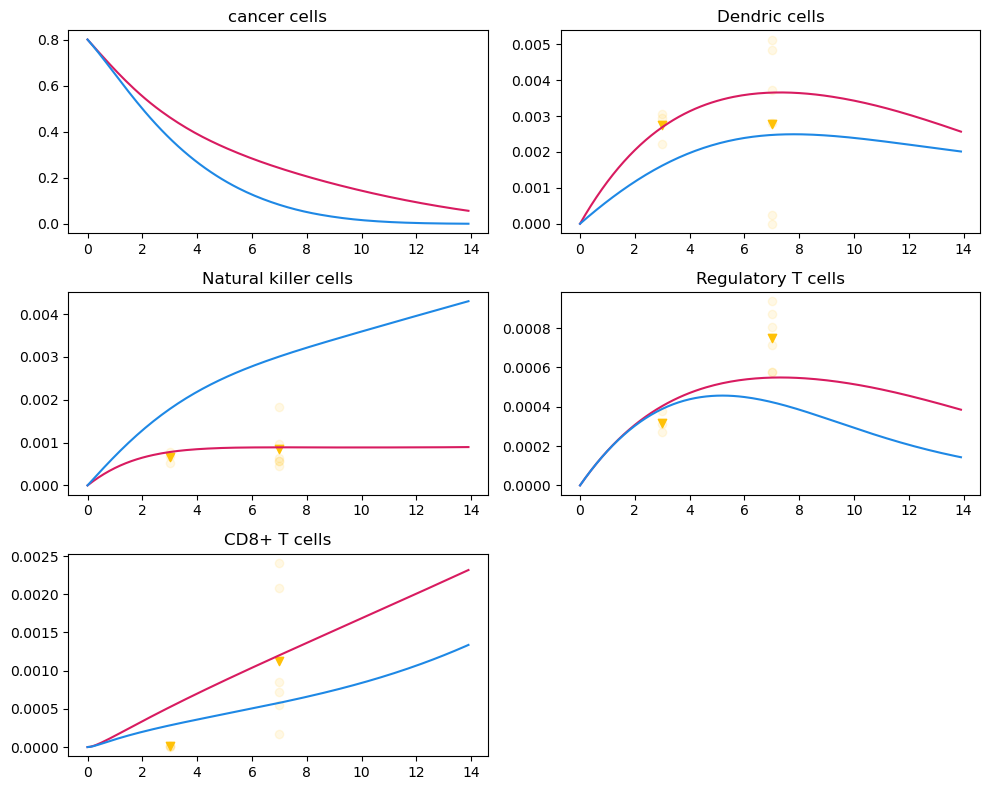

iteration 1322430 of 2593080 i.e. 50.998426581516966%
time : 2158.235256433487, time per iteration : 0.001632022304721979
iteration 1348360 of 2593080 i.e. 51.99839573017415%
time : 2198.684821367264, time per iteration : 0.0016306363444237918
minimum maximum rel error is 0.9726566835635326
{'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0002, 'd_T8': 0.01, 'sigma_N': 0.0002, 'd_D': 0.01, 'K_Tr': 0.005, 'd_N': 0.1}
minimum maximum rel error is 0.9725930022650228
{'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0002, 'd_T8': 0.01, 'sigma_N': 0.0002, 'd_D': 0.05, 'K_Tr': 0.005, 'd_N': 0.1}
minimum maximum rel error is 0.9725113569118792
{'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0002, 'd_T8': 0.01, 'sigma_N': 0.0002, 'd_D': 0.1, 'K_Tr': 0.005, 'd_N': 0.1}
minimum maximum rel error is 0.9723412817477375
{'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0002, 'd_T8': 0.01, 'sigma_N': 0.0002, '

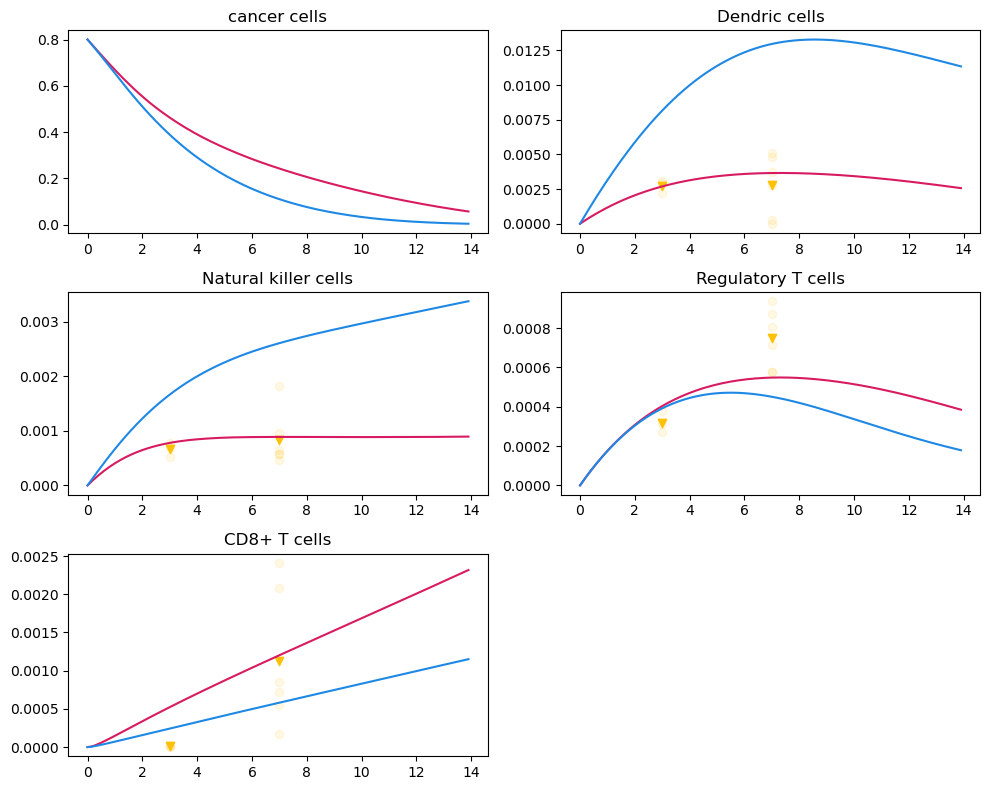

iteration 1452080 of 2593080 i.e. 55.99827232480293%
time : 2363.4013934135437, time per iteration : 0.0016275972352856204
iteration 1478010 of 2593080 i.e. 56.99824147346013%
time : 2405.1482725143433, time per iteration : 0.0016272882270852993
iteration 1503940 of 2593080 i.e. 57.99821062211733%
time : 2444.8529090881348, time per iteration : 0.0016256319461468774
iteration 1529870 of 2593080 i.e. 58.99817977077453%
time : 2484.597107410431, time per iteration : 0.0016240576698741925
iteration 1555800 of 2593080 i.e. 59.99814891943171%
time : 2525.0223615169525, time per iteration : 0.0016229736222631139


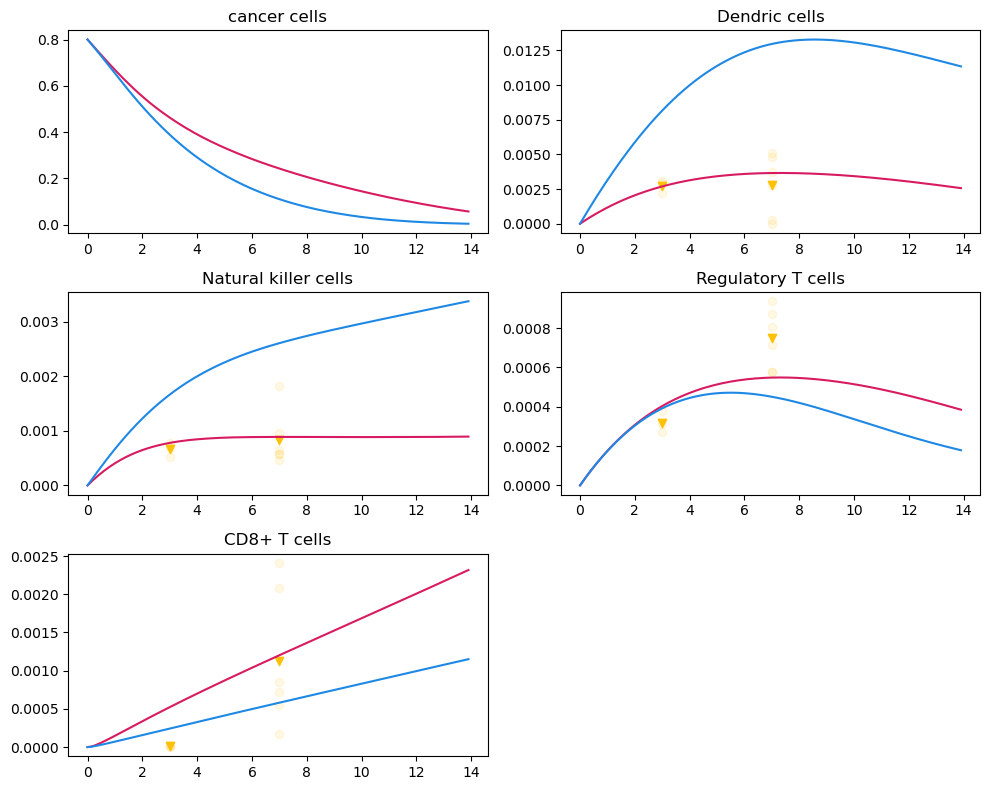

iteration 1581730 of 2593080 i.e. 60.998118068088914%
time : 2565.3999581336975, time per iteration : 0.0016218949872188664
iteration 1607660 of 2593080 i.e. 61.998087216746114%
time : 2606.297472715378, time per iteration : 0.0016211745473019032
iteration 1633590 of 2593080 i.e. 62.9980563654033%
time : 2646.5116579532623, time per iteration : 0.0016200586793217774
iteration 1659520 of 2593080 i.e. 63.998025514060494%
time : 2688.3712775707245, time per iteration : 0.0016199691944482288
iteration 1685450 of 2593080 i.e. 64.9979946627177%
time : 2731.386281490326, time per iteration : 0.0016205679678960075


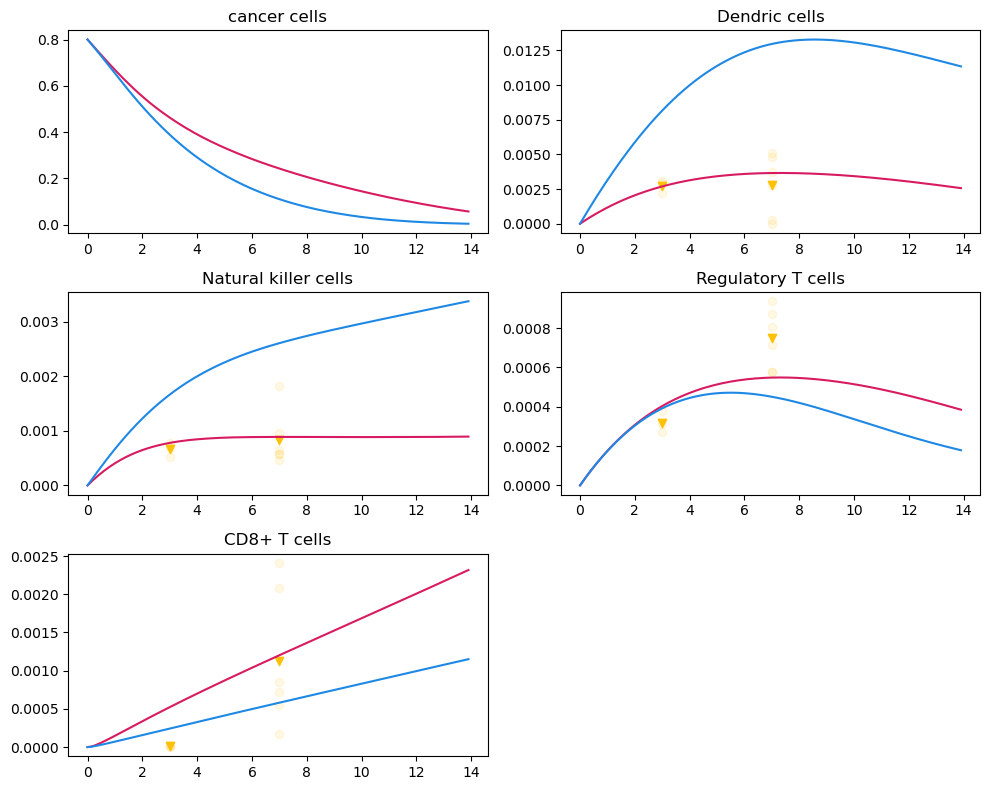

mean square rel error is 0.3891518050710838
{'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0002, 'd_D': 0.2, 'K_Tr': 0.005, 'd_N': 0.1}
mean square rel error is 0.3885821109272952
{'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0002, 'd_D': 0.2, 'K_Tr': 0.01, 'd_N': 0.1}
mean square rel error is 0.38580486946718284
{'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0005, 'd_D': 0.2, 'K_Tr': 0.005, 'd_N': 0.5}
mean square rel error is 0.3853686668717192
{'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.002, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0005, 'd_D': 0.2, 'K_Tr': 0.01, 'd_N': 0.5}
iteration 1711380 of 2593080 i.e. 65.99796381137489%
time : 2774.751650571823, time per iteration : 0.0016213533233833649
iteration 1737310 of 2593080 i.e. 66.99793296003207%
time : 2818.6478753089905, time per iteration : 0.

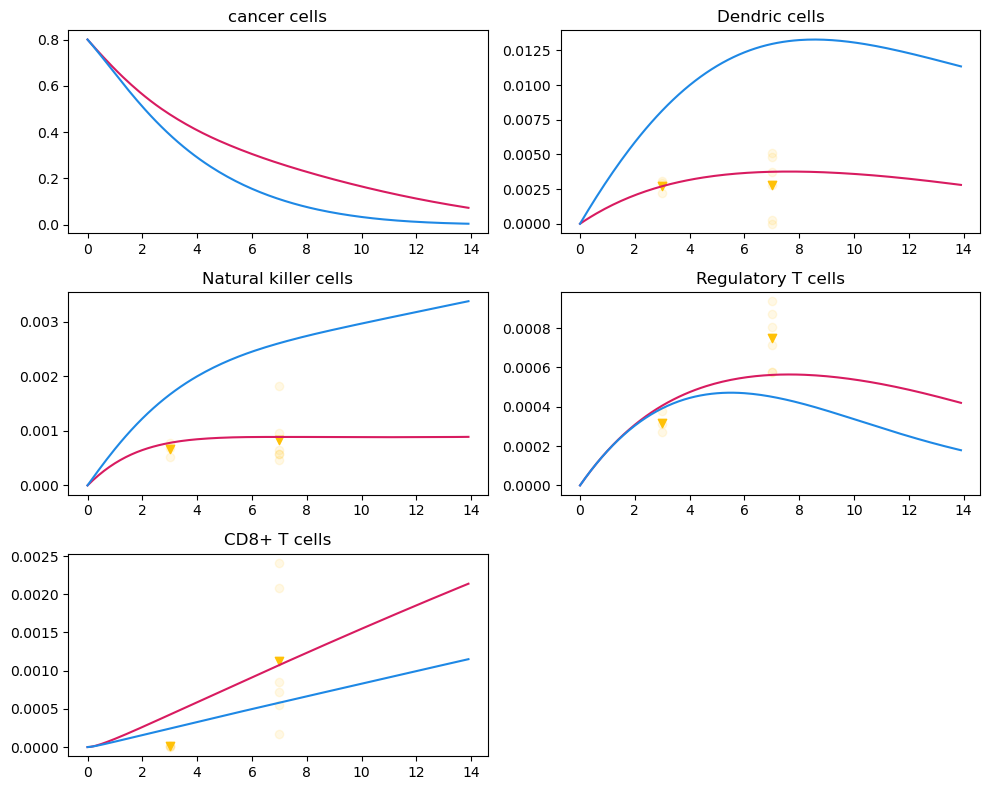

iteration 1841030 of 2593080 i.e. 70.99780955466086%
time : 2988.7395951747894, time per iteration : 0.0016234062427960378
iteration 1866960 of 2593080 i.e. 71.99777870331806%
time : 3030.503966331482, time per iteration : 0.001623229188805053
iteration 1892890 of 2593080 i.e. 72.99774785197526%
time : 3071.2900643348694, time per iteration : 0.0016225401710267735
iteration 1918820 of 2593080 i.e. 73.99771700063246%
time : 3113.312308549881, time per iteration : 0.0016225139974306506
iteration 1944750 of 2593080 i.e. 74.99768614928965%
time : 3155.878631591797, time per iteration : 0.0016227682898016696


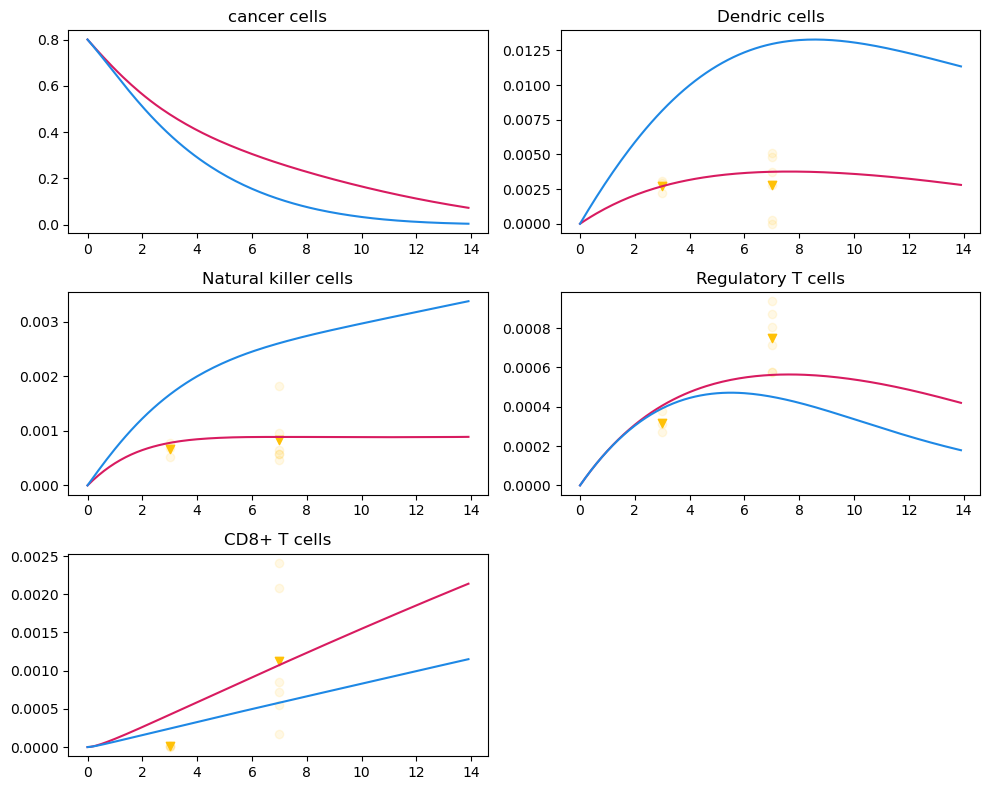

iteration 1970680 of 2593080 i.e. 75.99765529794684%
time : 3198.8315563201904, time per iteration : 0.0016232120670632423
iteration 1996610 of 2593080 i.e. 76.99762444660404%
time : 3242.817892074585, time per iteration : 0.0016241619004585697
iteration 2022540 of 2593080 i.e. 77.99759359526124%
time : 3286.730208158493, time per iteration : 0.0016250507817687132
iteration 2048470 of 2593080 i.e. 78.99756274391842%
time : 3330.7844376564026, time per iteration : 0.0016259864375150247
iteration 2074400 of 2593080 i.e. 79.99753189257562%
time : 3375.438159942627, time per iteration : 0.0016271876976198549


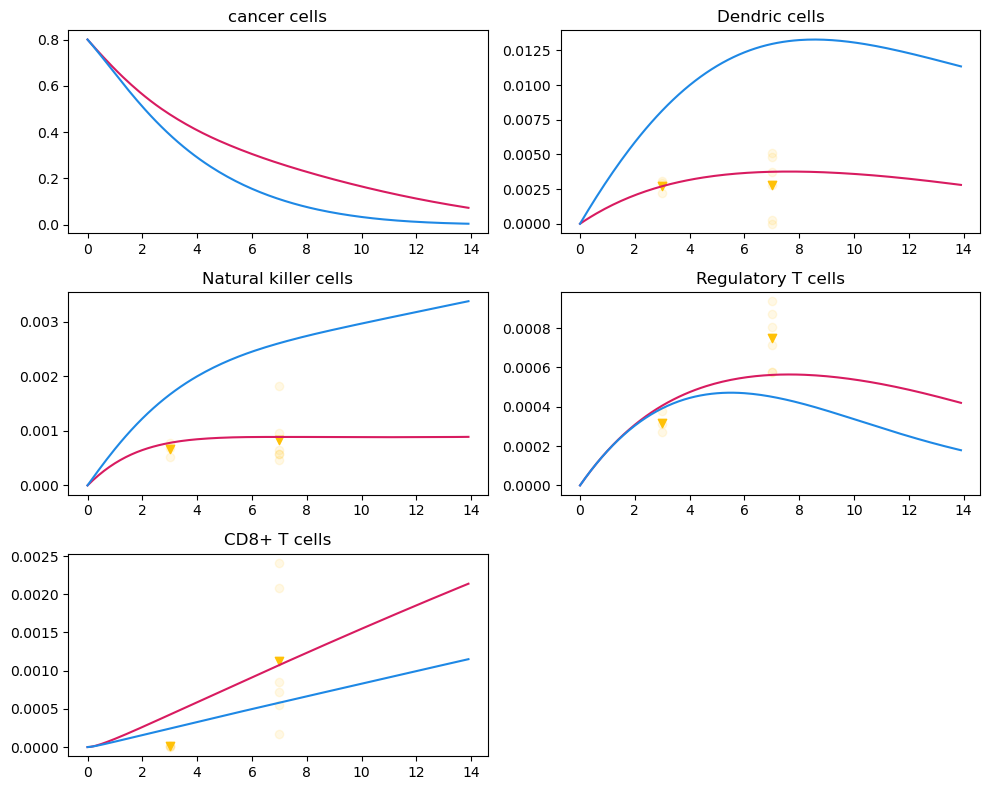

iteration 2100330 of 2593080 i.e. 80.99750104123282%
time : 3420.023113489151, time per iteration : 0.0016283265551076027
iteration 2126260 of 2593080 i.e. 81.99747018989002%
time : 3464.8693408966064, time per iteration : 0.0016295605151282564
iteration 2152190 of 2593080 i.e. 82.99743933854721%
time : 3509.720290184021, time per iteration : 0.0016307669351609388
iteration 2178120 of 2593080 i.e. 83.99740848720441%
time : 3555.376361131668, time per iteration : 0.0016323142715422786
iteration 2204050 of 2593080 i.e. 84.99737763586161%
time : 3601.148439884186, time per iteration : 0.0016338778339348861


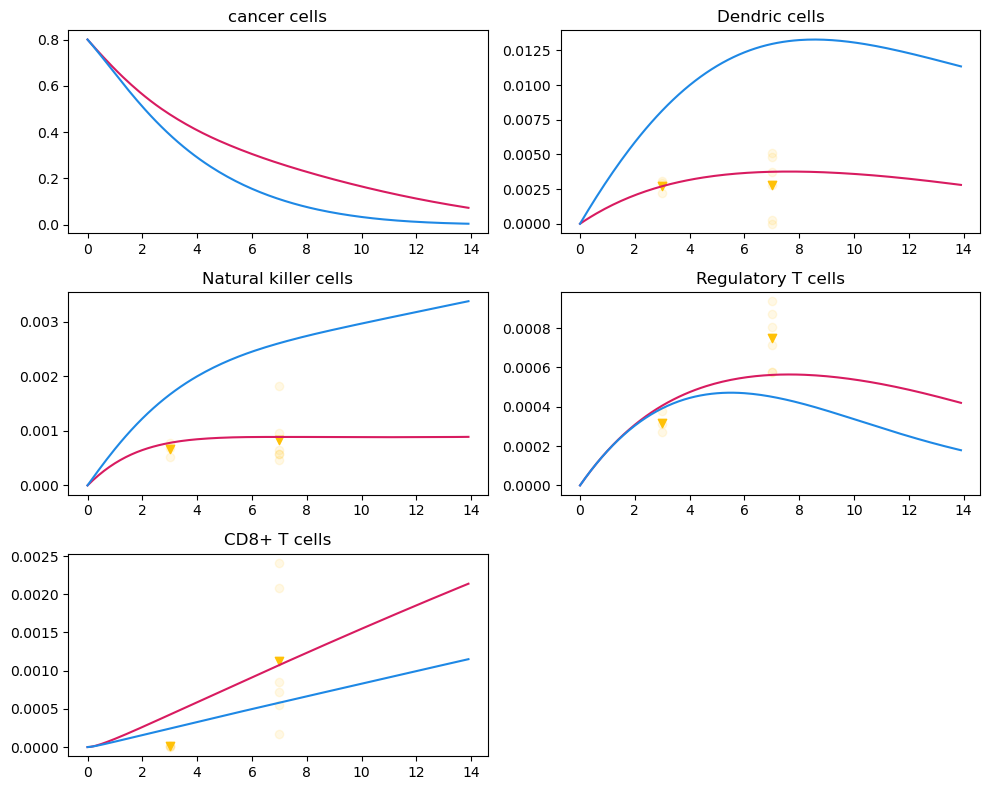

iteration 2229980 of 2593080 i.e. 85.9973467845188%
time : 3647.016982316971, time per iteration : 0.0016354482920550727
iteration 2255910 of 2593080 i.e. 86.99731593317598%
time : 3691.014261007309, time per iteration : 0.0016361531537194786


KeyboardInterrupt: 

In [18]:
import itertools
import time

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
minimum_maximum_distance = 10000

prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
plot_points = np.arange(0,prod,prod//20,dtype = int)
start_time = time.time()
for combo in itertools.product(*values):
    iters+=1
    time_passed = time.time()-start_time
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
        print(f"time : {time_passed}, time per iteration : {time_passed/iters}")
    if iters in plot_points:
        c1 = (216/255,27/255,96/255)
        c2 = (30/255,136/255,229/255)
        c3 = (255/255,193/255,7/255)
        c4 = (0/255,77/255,64/255)
        
        tspan = (0.0,14.0,)
        C_init     = mutagen_best_params['C_init']
        D_init     = mutagen_best_params['D_init']
        N_init     = mutagen_best_params['N_init']
        Tr_init    = mutagen_best_params['Tr_init']
        T8_init    = mutagen_best_params['T8_init']
        C0 = [C_init,D_init,N_init,Tr_init,T8_init]
        sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
        sol_mm = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (mutagen_best_params_mm,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
        
        t = sol.t
        y = sol.y
        t_mm = sol_mm.t
        y_mm = sol_mm.y
        
        
        fig,ax = plt.subplots(3,2,figsize = (10,8))
        cancer = ax[0,0]
        cancer.plot(t,y[0],color = c1)
        cancer.plot(t,y_mm[0],color = c2)
    
        cancer.set_title('cancer cells')
        D_cells = ax[0,1]
        D_cells.plot(t,y[1],color = c1,label = 'mean square error')
        D_cells.plot(t,y_mm[1],color = c2,label = 'min max error ')
        D_cells.set_title('Dendric cells')
        D_cells.scatter([3.0,7.0],mutagen_Ds[:2],alpha=1.0,marker ='v',color = c3)
        D_cells.scatter(scatter_mutagen_times,scatter_mutagen_Ds,alpha=0.1,color = c3)
        
        
        NK_cells = ax[1,0]
        NK_cells.plot(t,y[2],color = c1)
        NK_cells.plot(t,y_mm[2],color = c2)
        
        NK_cells.set_title('Natural killer cells')
        NK_cells.scatter(scatter_mutagen_times,scatter_mutagen_NKs,alpha=0.1,color = c3)
        NK_cells.scatter([3,7],mutagen_NKs[:2],alpha=1.0,marker ='v',color = c3)
        
        
        Treg = ax[1,1]
        Treg.plot(t,y[3],color = c1)
        Treg.plot(t,y_mm[3],color = c2)
        
        Treg.set_title('Regulatory T cells')
        Treg.scatter(scatter_mutagen_times,scatter_mutagen_Tregs,alpha=0.1,color = c3)
        Treg.scatter([3,7],mutagen_Tregs[:2],alpha=1.0,marker ='v',color = c3)
        # {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
        T8 = ax[2,0]
        T8.plot(t,y[4],color = c1)
        T8.plot(t,y_mm[4],color = c2)
        
        T8.set_title('CD8+ T cells')
        T8.scatter(scatter_mutagen_times,scatter_mutagen_T8s,alpha=0.1,color = c3)
        T8.scatter([3,7],mutagen_T8s[:2],alpha=1.0,marker ='v',color = c3)
        
        
        extra_plot = ax[2,1]
        extra_plot.set_visible(False)
        
        
        plt.tight_layout()
        plt.show()
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']
    

    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(np.array(sol.y[1:]),true_mutagen)
        distance_max = max_error_rel(np.array(sol.y[1:]),true_mutagen)
        if minimum_distance>distance:
            minimum_distance = distance
            mutagen_best_params = params.copy()
            print(f"mean square rel error is {distance}")
            print({k:mutagen_best_params[k] for k in params_to_change.keys()})
        if minimum_maximum_distance > distance_max:
            minimum_maximum_distance = distance_max
            mutagen_best_params_mm = params.copy()
            print(f"minimum maximum rel error is {minimum_maximum_distance}")
            print({k:mutagen_best_params_mm[k] for k in params_to_change.keys()})
        
print(f'The minimum error is {minimum_distance}')
print({k:mutagen_best_params[k] for k in params_to_change.keys()})

In [74]:

mutagen_best_params = orig_params.copy()
mutagen_best_params.update({'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.01, 'd_N': 0.5} )
print(mutagen_best_params)
print({k:mutagen_best_params[k] for k in params_to_change.keys()})
# mutagen_best_params = {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0005, 'd_N': 0.15, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.075, 'lambda_T8_comb': 0.00125, 'K_Tr': 3e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}

{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.005, 'K_C': 0.4, 'd_D': 1.0, 'sigma_N': 0.0005, 'd_N': 0.5, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'lambda_T8_comb': 0.0002, 'K_Tr': 0.01, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
{'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.01, 'd_N': 0.5}


/home/participant/miniforge3/envs/mibproject/lib/python3.11/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `abs_tol`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


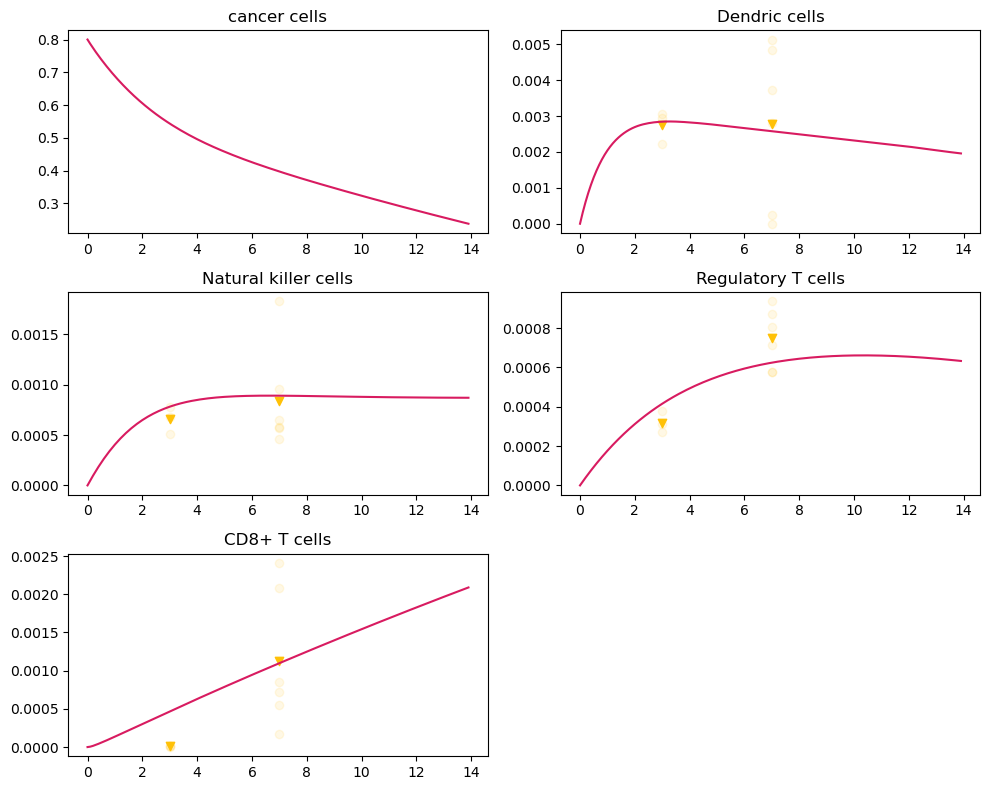

In [75]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,14.0,)
C_init     = mutagen_best_params['C_init']
D_init     = mutagen_best_params['D_init']
N_init     = mutagen_best_params['N_init']
Tr_init    = mutagen_best_params['Tr_init']
T8_init    = mutagen_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1)
D_cells.set_title('Dendric cells')
D_cells.scatter([3.0,7.0],mutagen_Ds[:2],alpha=1.0,marker ='v',color = c3)
D_cells.scatter(scatter_mutagen_times,scatter_mutagen_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_mutagen_times,scatter_mutagen_NKs,alpha=0.1,color = c3)
NK_cells.scatter([3,7],mutagen_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_mutagen_times,scatter_mutagen_Tregs,alpha=0.1,color = c3)
Treg.scatter([3,7],mutagen_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_mutagen_times,scatter_mutagen_T8s,alpha=0.1,color = c3)
T8.scatter([3,7],mutagen_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()

In [14]:
#Fitting non-mutagen treatment

In [76]:

true_no_mutagen = np.array([no_mutagen_Ds[:2],no_mutagen_NKs[:2],no_mutagen_Tregs[:2],no_mutagen_T8s[:2]])

In [83]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[2e-5],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25,0.4,0.5,0.6,0.7,1.0],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5,1.0,2.0]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4],'d_T8': [0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# initial sweep
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,9.5e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3,4e-3,5e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,5e-3,1e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.0025, 'lambda_Tr_comb': 0.0003, 'sigma_N': 0.00035} error 0.5
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,7.5e-5,1e-4,2e-4,7.5e-4,9e-4,1e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.125e-3,2.5e-3,3.0e-3,4e-3,5e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,5e-3,1e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,3.75e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.0025, 'lambda_Tr_comb': 0.0003, 'sigma_N': 0.00035}
params_to_change = {'lambda_T8_comb':[5e-6,7.5e-6,1e-5,2.5e-6,5e-5,7.5e-5,1e-4,2e-4,7.5e-4,9e-4,1e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.125e-3,2.5e-3,3.0e-3,4e-3,5e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,5e-3,1e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,3.75e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 5e-05, 'lambda_DC_comb': 0.0014, 'lambda_Tr_comb': 0.0003, 'sigma_N': 0.00025}
# {'lambda_T8_comb': 5e-05, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'sigma_N': 0.0005}
params_to_change = {'lambda_T8_comb':[5e-6,7.5e-6,1e-5,2.5e-6,4e-5,5e-5,6e-5,7.5e-5,1e-4,2e-4,7.5e-4,9e-4,1e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.125e-3,2.5e-3,3.0e-3,4e-3,5e-3,7.5e-3,1e-2,2e-2],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,4e-4,5e-4,1e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,3.75e-4,4e-4,5e-4,1e-3,1.5e-3,2e-3]}
# {'lambda_T8_comb': 4e-05, 'lambda_DC_comb': 0.0075, 'lambda_Tr_comb': 0.0004, 'sigma_N': 0.001}
params = mutagen_best_params.copy()

In [84]:
import itertools
import time

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
minimum_maximum_distance = 10000
prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
start_time = time.time()
for combo in itertools.product(*values):
    iters+=1
    time_passed = time.time()-start_time
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
        print(f"time : {time_passed}, time per iteration : {time_passed/iters}")
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(np.array(sol.y[1:]),true_no_mutagen)
        distance_max = max_error_rel(np.array(sol.y[1:]),true_no_mutagen)
        if minimum_distance>distance:
            minimum_distance = distance
            no_mutagen_best_params = params.copy()
            print(distance)
            print({k:no_mutagen_best_params[k] for k in params_to_change.keys()})
        if minimum_maximum_distance > distance_max:
            minimum_maximum_distance = distance_max
            no_mutagen_best_params_mm = params.copy()
            print(f"minimum maximum rel error is {minimum_maximum_distance}")
            print({k:no_mutagen_best_params_mm[k] for k in params_to_change.keys()})
print(f'The minimum error is {minimum_distance}')
print({k:no_mutagen_best_params[k] for k in params_to_change.keys()})

9.980401936281693
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 5e-05}
minimum maximum rel error is 3.896833405354798
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 5e-05}
9.017033918740406
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 7.5e-05}
8.777788923825623
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 9e-05}
8.676466560249574
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 0.0001}
8.408683731049893
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 0.0002}
8.407907139874998
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 0.00025}
8.157065155291576
{'lambda_T8_comb': 5e-06, 'lambda_DC_comb': 0.00075, 'lambda_Tr_comb': 0.00015, 'sigma_N': 5e-05}
minimum maximum rel error is 3.8154762876287

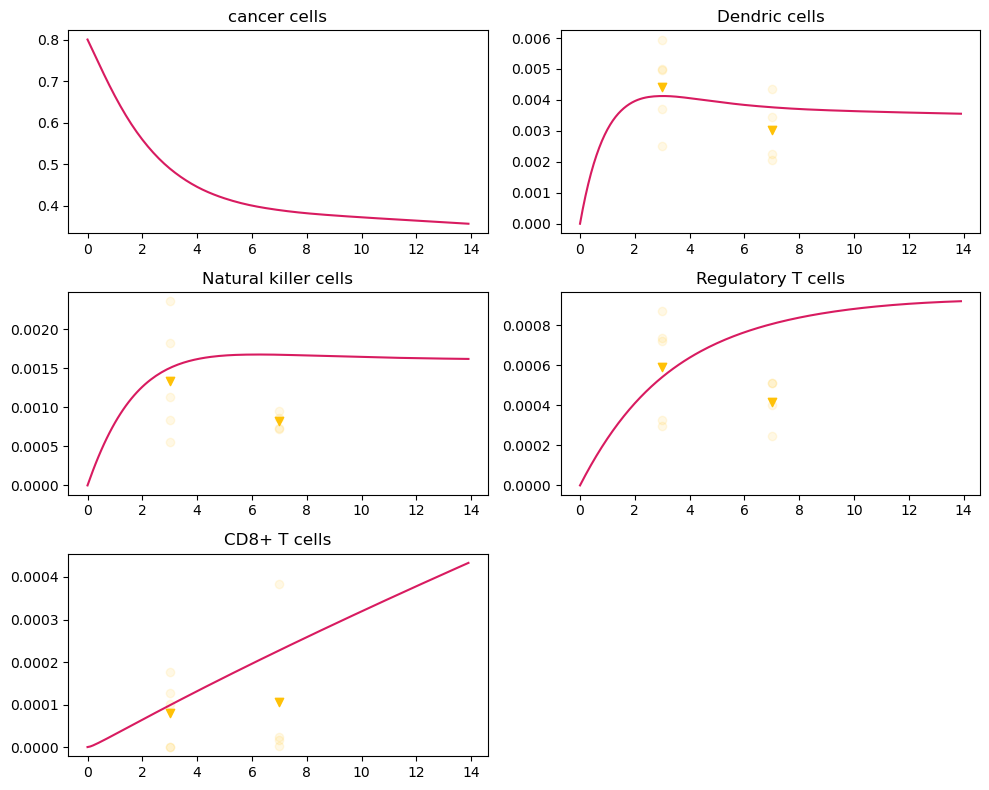

In [85]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,14.0,)
C_init     = no_mutagen_best_params['C_init']
D_init     = no_mutagen_best_params['D_init']
N_init     = no_mutagen_best_params['N_init']
Tr_init    = no_mutagen_best_params['Tr_init']
T8_init    = no_mutagen_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1)
D_cells.set_title('Dendric cells')
D_cells.scatter([3.0,7.0],no_mutagen_Ds[:2],alpha=1.0,marker ='v',color = c3)
D_cells.scatter(scatter_no_mutagen_times,scatter_no_mutagen_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_no_mutagen_times,scatter_no_mutagen_NKs,alpha=0.1,color = c3)
NK_cells.scatter([3,7],no_mutagen_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_no_mutagen_times,scatter_no_mutagen_Tregs,alpha=0.1,color = c3)
Treg.scatter([3,7],no_mutagen_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_no_mutagen_times,scatter_no_mutagen_T8s,alpha=0.1,color = c3)
T8.scatter([3,7],no_mutagen_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()

In [19]:
#Fitting no treatment
#Fitting no treatment

In [20]:
# objective_function_day3 = {'Ds':no_treatment_Ds[0],
#                           'NKs':no_treatment_NKs[0],
#                           'Tregs':no_treatment_Tregs[0],|
#                           'T8s':no_treatment_T8s[0]}
# objective_function_day7 = {'Ds':no_treatment_Ds[1],
#                           'NKs':no_treatment_NKs[1],
#                           'Tregs':no_treatment_Tregs[1],
#                           'T8s':no_treatment_T8s[1]}
true_no_treatment = np.array([no_treatment_Ds[:2],no_treatment_NKs[:2],no_treatment_Tregs[:2],no_treatment_T8s[:2]])

In [21]:
# objective_function_day3 = {'Ds':no_treatment_Ds[0],
#                           'NKs':no_treatment_NKs[0],
#                           'Tregs':no_treatment_Tregs[0],|
#                           'T8s':no_treatment_T8s[0]}
# objective_function_day7 = {'Ds':no_treatment_Ds[1],
#                           'NKs':no_treatment_NKs[1],
#                           'Tregs':no_treatment_Tregs[1],
#                           'T8s':no_treatment_T8s[1]}
true_no_treatment = np.array([no_treatment_Ds[:2],no_treatment_NKs[:2],no_treatment_Tregs[:2],no_treatment_T8s[:2]])

In [26]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[2e-5],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25,0.4,0.5,0.6,0.7,1.0],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5,1.0,2.0]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4],'d_T8': [0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
#initial sweep
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.0014, 'lambda_Tr_comb': 0.000275, 'sigma_N': 0.00025}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,6e-5,7e-5,8e-5,1e-4,2e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,5e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.25e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}

params = mutagen_best_params.copy()

In [27]:
import itertools
import time

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
minimum_maximum_distance = 10000
prod = 1
for k in values:
    prod *= len(k)

iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
start_time = time.time()
for combo in itertools.product(*values):
    iters+=1
    time_passed = time.time()-start_time
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
        print(f"time : {time_passed}, time per iteration : {time_passed/iters}")
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(np.array(sol.y[1:]),true_no_treatment)
        distance_max = max_error_rel(np.array(sol.y[1:]),true_no_treatment)
        if minimum_distance>distance:
            minimum_distance = distance
            no_treatment_best_params = params.copy()
            print(distance)
            print({k:no_treatment_best_params[k] for k in params_to_change.keys()})
        if minimum_maximum_distance > distance_max:
            minimum_maximum_distance = distance_max
            no_treatment_best_params_mm = params.copy()
            print(f"minimum maximum rel error is {minimum_maximum_distance}")
            print({k:no_treatment_best_params_mm[k] for k in params_to_change.keys()})
print(f'The minimum error is {minimum_distance}')
print({k:no_treatment_best_params[k] for k in params_to_change.keys()})

7.219773027419145
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 5e-05}
minimum maximum rel error is 4.292329285803807
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 5e-05}
7.104097772669445
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 7.5e-05}
minimum maximum rel error is 4.2922444323900315
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 7.5e-05}
7.0785102931148005
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 9e-05}
minimum maximum rel error is 4.292194263580879
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 9e-05}
7.0681967407784825
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 0.0001}
minimum maximum rel error is 4.292161109350009
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, '

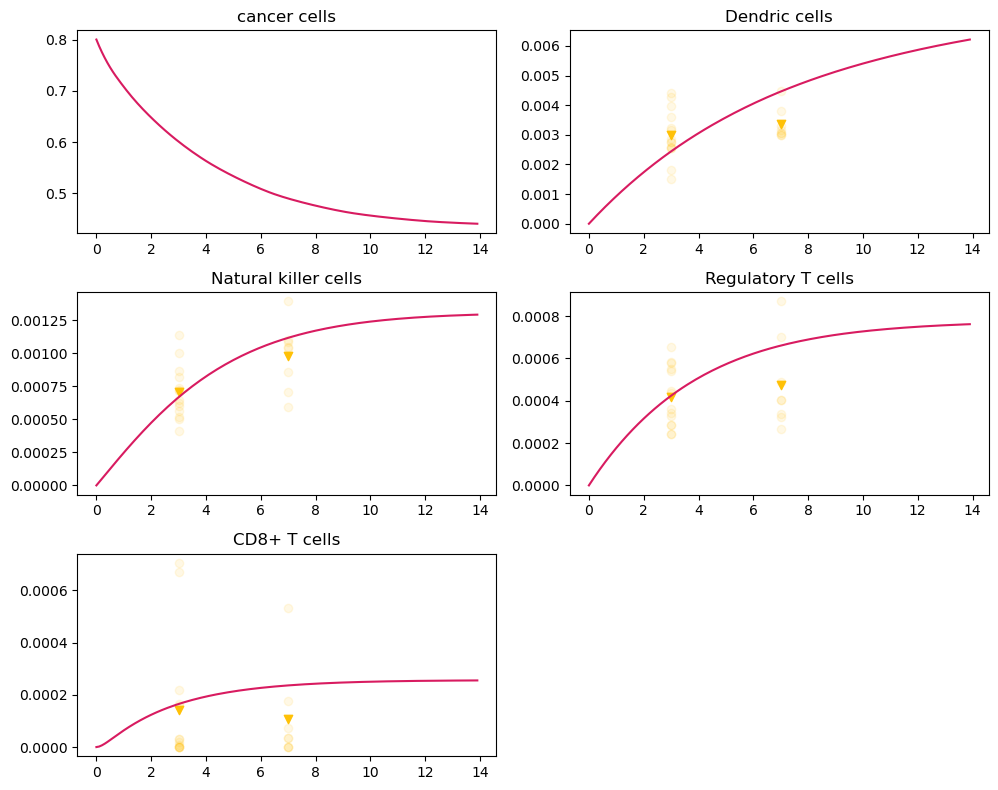

In [28]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,14.0,)
C_init     = no_treatment_best_params['C_init']
D_init     = no_treatment_best_params['D_init']
N_init     = no_treatment_best_params['N_init']
Tr_init    = no_treatment_best_params['Tr_init']
T8_init    = no_treatment_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_treatment_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1)
D_cells.set_title('Dendric cells')
D_cells.scatter([3.0,7.0],no_treatment_Ds[:2],alpha=1.0,marker ='v',color = c3)
D_cells.scatter(scatter_no_treatment_times,scatter_no_treatment_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_no_treatment_times,scatter_no_treatment_NKs,alpha=0.1,color = c3)
NK_cells.scatter([3,7],no_treatment_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_no_treatment_times,scatter_no_treatment_Tregs,alpha=0.1,color = c3)
Treg.scatter([3,7],no_treatment_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_no_treatment_times,scatter_no_treatment_T8s,alpha=0.1,color = c3)
T8.scatter([3,7],no_treatment_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()

In [29]:

# best_params.update({'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.0013, 'd_T8': 1e-05, 'sigma_N': 0.00035, 'K_Tr': 2.25e-05, 'd_N': 0.22})

In [89]:
#fitting no treatment no mutagen
true_no_treatment_no_mutagen = np.array([no_treatment_no_mutagen_Ds[:2],no_treatment_no_mutagen_NKs[:2],no_treatment_no_mutagen_Tregs[:2],no_treatment_no_mutagen_T8s[:2]])

In [98]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[2e-5],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25,0.4,0.5,0.6,0.7,1.0],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5,1.0,2.0]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4],'d_T8': [0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
#initial sweep
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.0014, 'lambda_Tr_comb': 0.000275, 'sigma_N': 0.00025}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,6e-5,7e-5,8e-5,1e-4,2e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,5e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.25e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0015, 'lambda_Tr_comb': 0.0002, 'sigma_N': 0.00025}
params_to_change = {'lambda_T8_comb':[5e-7,1e-6,1.5e-6,2e-6,2.25e-6,2.5e-6,3e-6,5e-6,7.5e-6,1e-5,5e-5,6e-5,7e-5,8e-5,1e-4,2e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,1.75e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1e-4,1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,5e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.25e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0015, 'lambda_Tr_comb': 0.0002, 'sigma_N': 0.00025}
# {'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0015, 'lambda_Tr_comb': 0.0002, 'sigma_N': 0.00025}
# {'lambda_T8_comb': 2.5e-06, 'lambda_DC_comb': 0.0095, 'lambda_Tr_comb': 0.00025, 'sigma_N': 0.0005}
# {'lambda_T8_comb': 3e-06, 'lambda_DC_comb': 0.0095, 'lambda_Tr_comb': 0.00025, 'sigma_N': 0.0005}
params = mutagen_best_params.copy()

In [99]:
import itertools
import time

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
minimum_maximum_distance = 10000
prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
start_time = time.time()
for combo in itertools.product(*values):
    iters+=1
    time_passed = time.time()-start_time
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
        print(f"time : {time_passed}, time per iteration : {time_passed/iters}")
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(np.array(sol.y[1:]),true_no_treatment_no_mutagen)
        distance_max = max_error_rel(np.array(sol.y[1:]),true_no_treatment_no_mutagen)
        if minimum_distance>distance:
            minimum_distance = distance
            no_treatment_no_mutagen_best_params = params.copy()
            print(distance)
            print({k:no_treatment_no_mutagen_best_params[k] for k in params_to_change.keys()})
        if minimum_maximum_distance > distance_max:
            minimum_maximum_distance = distance_max
            no_treatment_no_mutagen_best_params_mm = params.copy()
            print(f"minimum maximum rel error is {minimum_maximum_distance}")
            print({k:no_treatment_no_mutagen_best_params_mm[k] for k in params_to_change.keys()})
print(f'The minimum error is {minimum_distance}')
print({k:no_treatment_no_mutagen_best_params[k] for k in params_to_change.keys()})

7.266015372481295
{'lambda_T8_comb': 5e-07, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.0001, 'sigma_N': 5e-05}
minimum maximum rel error is 3.44241129942646
{'lambda_T8_comb': 5e-07, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.0001, 'sigma_N': 5e-05}
6.642442042520857
{'lambda_T8_comb': 5e-07, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.0001, 'sigma_N': 7.5e-05}
6.4938598852543015
{'lambda_T8_comb': 5e-07, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.0001, 'sigma_N': 9e-05}
6.432886275369518
{'lambda_T8_comb': 5e-07, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.0001, 'sigma_N': 0.0001}
6.30188211650575
{'lambda_T8_comb': 5e-07, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.0001, 'sigma_N': 0.0002}
6.2996151080504275
{'lambda_T8_comb': 5e-07, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.00015, 'sigma_N': 0.0002}
5.842486467587524
{'lambda_T8_comb': 5e-07, 'lambda_DC_comb': 0.00075, 'lambda_Tr_comb': 0.0001, 'sigma_N': 5e-05}
minimum maximum rel error is 3.0564182414940433
{'la

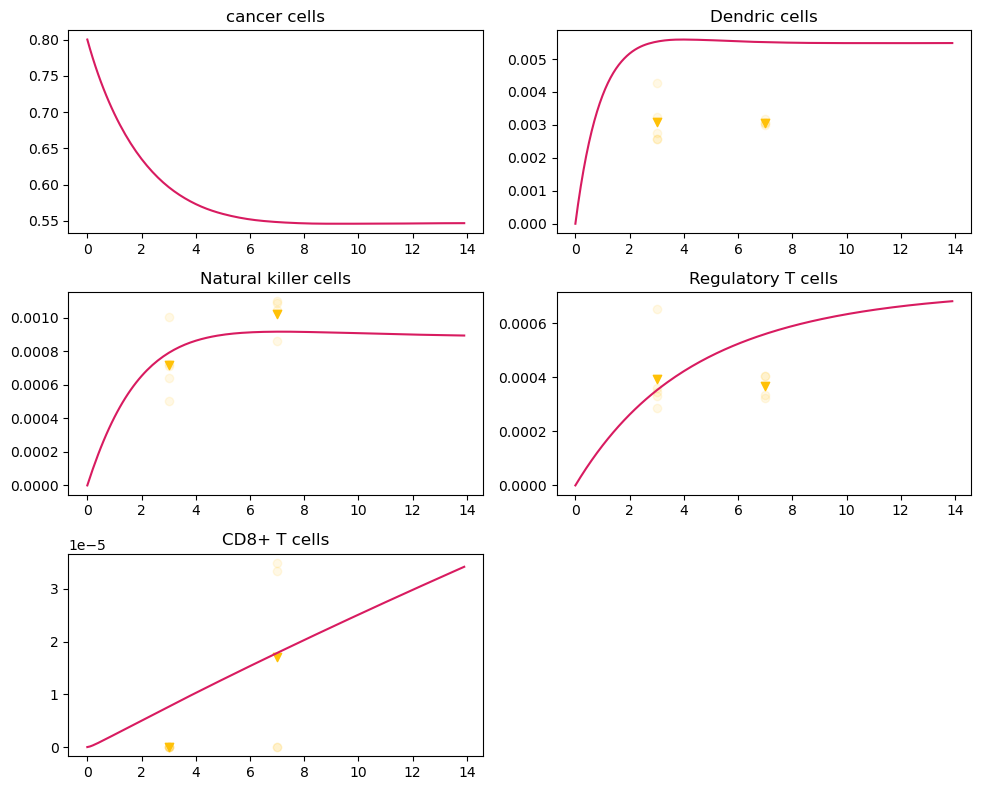

In [100]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,14.0,)
C_init     = no_treatment_no_mutagen_best_params['C_init']
D_init     = no_treatment_no_mutagen_best_params['D_init']
N_init     = no_treatment_no_mutagen_best_params['N_init']
Tr_init    = no_treatment_no_mutagen_best_params['Tr_init']
T8_init    = no_treatment_no_mutagen_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_treatment_no_mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1)
D_cells.set_title('Dendric cells')
D_cells.scatter([3.0,7.0],no_treatment_no_mutagen_Ds[:2],alpha=1.0,marker ='v',color = c3)
D_cells.scatter(scatter_no_treatment_no_mutagen_times,scatter_no_treatment_no_mutagen_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_no_treatment_no_mutagen_times,scatter_no_treatment_no_mutagen_NKs,alpha=0.1,color = c3)
NK_cells.scatter([3,7],no_treatment_no_mutagen_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_no_treatment_no_mutagen_times,scatter_no_treatment_no_mutagen_Tregs,alpha=0.1,color = c3)
Treg.scatter([3,7],no_treatment_no_mutagen_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_no_treatment_no_mutagen_times,scatter_no_treatment_no_mutagen_T8s,alpha=0.1,color = c3)
T8.scatter([3,7],no_treatment_no_mutagen_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()

In [103]:
#fitting no treatment mutagen
true_no_treatment_mutagen = np.array([no_treatment_mutagen_Ds[:2],no_treatment_mutagen_NKs[:2],no_treatment_mutagen_Tregs[:2],no_treatment_mutagen_T8s[:2]])

In [111]:
params_to_change = {'lambda_DC_comb':[4e-5,4e-4,4e-3,4e-2],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3],'sigma_N':[5e-5,5e-4,5e-3],'lambda_T8_comb':[1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2]}
params_to_change = {'lambda_DC_comb':[5e-4,6e-4,7e-4,8e-4,9e-4,1e-3,2e-3,3e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,3e-4,4e-4,5e-4,5e-3],'lambda_T8_comb':[1e-5,1e-4,1e-3,0.5e-2,1e-2],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25],'d_N':[0.9,0.1,0.11],'K_Tr': [2.0e-5,2.5e-5,3.0e-5]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[2e-5],'d_T8': [0.00001,0.0005,0.001,0.002,0.075,0.1,0.18,0.25,0.4,0.5,0.6,0.7,1.0],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5,1.0,2.0]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4],'d_T8': [0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'d_T8': [0.01,0.075,0.1,0.18,0.25,0.4,0.5,0.6],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4],'K_Tr': [1.0e-5,1.25e-5,1.5e-5,2.0e-5,2.25e-5,3e-5],'d_N':[0.1,0.11,0.13,0.15,0.16,0.17,0.175,0.18,0.2,0.22,0.5]}
#initial sweep
params_to_change = {'lambda_T8_comb':[1e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 0.0001, 'lambda_DC_comb': 0.0014, 'lambda_Tr_comb': 0.000275, 'sigma_N': 0.00025}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,6e-5,7e-5,8e-5,1e-4,2e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,5e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.25e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0015, 'lambda_Tr_comb': 0.0002, 'sigma_N': 0.00025}
params_to_change = {'lambda_T8_comb':[2.5e-6,5e-6,7.5e-6,1e-5,5e-5,6e-5,7e-5,8e-5,1e-4,2e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,1.75e-3,2.0e-3,2.5e-3,3.0e-3],'lambda_Tr_comb':[1e-4,1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,5e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.25e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0015, 'lambda_Tr_comb': 0.0002, 'sigma_N': 0.00025}
# {'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.00175, 'lambda_Tr_comb': 0.000275, 'sigma_N': 0.00025}
params_to_change = {'lambda_T8_comb':[2.5e-6,5e-6,7.5e-6,1e-5,5e-5,6e-5,7e-5,8e-5,1e-4,2e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3],'lambda_DC_comb':[5e-4,7.5e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,1.75e-3,2.0e-3,2.5e-3,3.0e-3,9.5e-3,1e-2,2e-2],'lambda_Tr_comb':[1e-4,1.5e-4,2e-4,2.5e-4,2.75e-4,3e-4,4e-4,5e-4],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.25e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4]}
# {'lambda_T8_comb': 7e-05, 'lambda_DC_comb': 0.0095, 'lambda_Tr_comb': 0.0003, 'sigma_N': 0.0005}
params = mutagen_best_params.copy()

In [112]:
import itertools
import time

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
minimum_maximum_distance = 10000
prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
start_time = time.time()
for combo in itertools.product(*values):
    iters+=1
    time_passed = time.time()-start_time
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
        print(f"time : {time_passed}, time per iteration : {time_passed/iters}")
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(np.array(sol.y[1:]),true_no_treatment_mutagen)
        distance_max = max_error_rel(np.array(sol.y[1:]),true_no_treatment_mutagen)
        if minimum_distance>distance:
            minimum_distance = distance
            no_treatment_mutagen_best_params = params.copy()
            print(distance)
            print({k:no_treatment_mutagen_best_params[k] for k in params_to_change.keys()})
        if minimum_maximum_distance > distance_max:
            minimum_maximum_distance = distance_max
            no_treatment_mutagen_best_params_mm = params.copy()
            print(f"minimum maximum rel error is {minimum_maximum_distance}")
            print({k:no_treatment_mutagen_best_params_mm[k] for k in params_to_change.keys()})
print(f'The minimum error is {minimum_distance}')
print({k:no_treatment_mutagen_best_params[k] for k in params_to_change.keys()})

33.31465819423675
{'lambda_T8_comb': 2.5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.0001, 'sigma_N': 5e-05}
minimum maximum rel error is 9.38761646820158
{'lambda_T8_comb': 2.5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.0001, 'sigma_N': 5e-05}
33.22405014240748
{'lambda_T8_comb': 2.5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.0001, 'sigma_N': 7.5e-05}
33.2126948438278
{'lambda_T8_comb': 2.5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.0001, 'sigma_N': 9e-05}
33.21191760814047
{'lambda_T8_comb': 2.5e-06, 'lambda_DC_comb': 0.0005, 'lambda_Tr_comb': 0.0001, 'sigma_N': 0.0001}
26.28510384978836
{'lambda_T8_comb': 2.5e-06, 'lambda_DC_comb': 0.00075, 'lambda_Tr_comb': 0.0001, 'sigma_N': 5e-05}
minimum maximum rel error is 8.333757609143381
{'lambda_T8_comb': 2.5e-06, 'lambda_DC_comb': 0.00075, 'lambda_Tr_comb': 0.0001, 'sigma_N': 5e-05}
26.153402463802262
{'lambda_T8_comb': 2.5e-06, 'lambda_DC_comb': 0.00075, 'lambda_Tr_comb': 0.0001, 'sigma_N': 7.5e-05}
26.1288

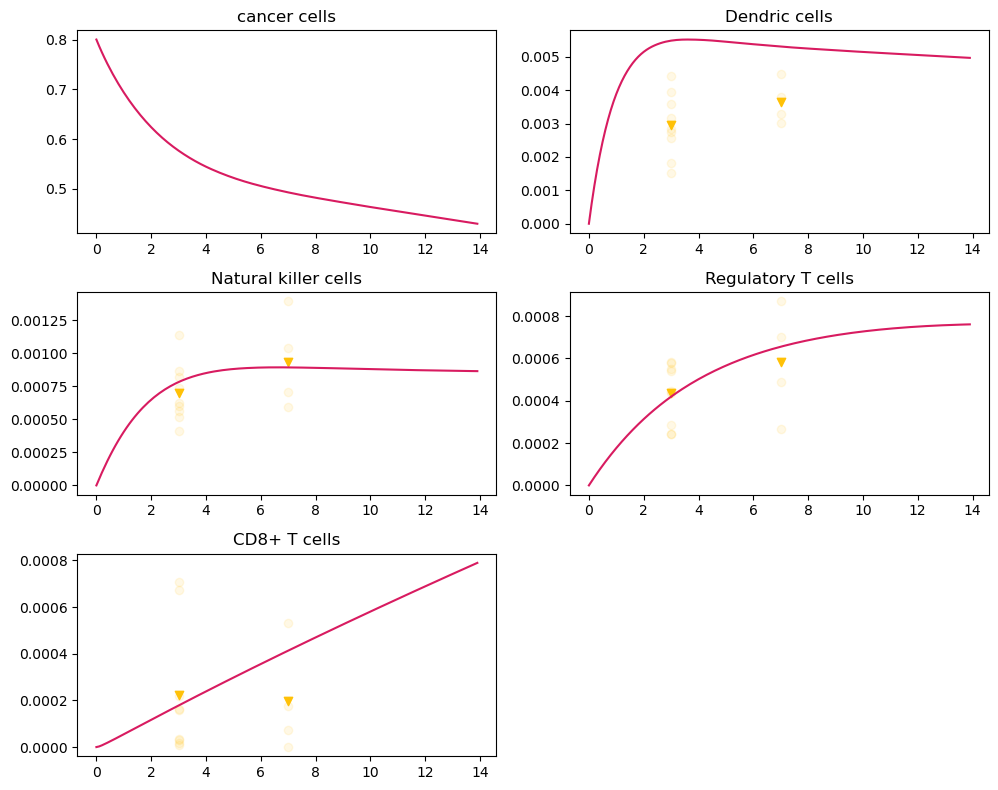

In [113]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,14.0,)
C_init     = no_treatment_mutagen_best_params['C_init']
D_init     = no_treatment_mutagen_best_params['D_init']
N_init     = no_treatment_mutagen_best_params['N_init']
Tr_init    = no_treatment_mutagen_best_params['Tr_init']
T8_init    = no_treatment_mutagen_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_treatment_mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1)
D_cells.set_title('Dendric cells')
D_cells.scatter([3.0,7.0],no_treatment_mutagen_Ds[:2],alpha=1.0,marker ='v',color = c3)
D_cells.scatter(scatter_no_treatment_mutagen_times,scatter_no_treatment_mutagen_Ds,alpha=0.1,color = c3)


NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_no_treatment_mutagen_times,scatter_no_treatment_mutagen_NKs,alpha=0.1,color = c3)
NK_cells.scatter([3,7],no_treatment_mutagen_NKs[:2],alpha=1.0,marker ='v',color = c3)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_no_treatment_mutagen_times,scatter_no_treatment_mutagen_Tregs,alpha=0.1,color = c3)
Treg.scatter([3,7],no_treatment_mutagen_Tregs[:2],alpha=1.0,marker ='v',color = c3)
# {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0002, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_no_treatment_mutagen_times,scatter_no_treatment_mutagen_T8s,alpha=0.1,color = c3)
T8.scatter([3,7],no_treatment_mutagen_T8s[:2],alpha=1.0,marker ='v',color = c3)


extra_plot = ax[2,1]
extra_plot.set_visible(False)


plt.tight_layout()
plt.show()

In [8]:
mutagen_best_params = orig_params.copy()
mutagen_best_params.update({'lambda_T8_comb': 0.0002, 'lambda_DC_comb': 0.005, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'sigma_N': 0.0005, 'd_D': 1.0, 'K_Tr': 0.01, 'd_N': 0.5} )
no_mutagen_best_params = mutagen_best_params.copy()
no_mutagen_best_params.update({'lambda_T8_comb': 4e-05, 'lambda_DC_comb': 0.0075, 'lambda_Tr_comb': 0.0004, 'sigma_N': 0.001})
no_treatment_no_mutagen_best_params = mutagen_best_params.copy()
no_treatment_no_mutagen_best_params.update({'lambda_T8_comb': 3e-06, 'lambda_DC_comb': 0.0095, 'lambda_Tr_comb': 0.00025, 'sigma_N': 0.0005})
no_treatment_mutagen_best_params = mutagen_best_params.copy()
no_treatment_mutagen_best_params.update({'lambda_T8_comb': 7e-05, 'lambda_DC_comb': 0.0095, 'lambda_Tr_comb': 0.0003, 'sigma_N': 0.0005})

print(mutagen_best_params)
print(no_treatment_no_mutagen_best_params)

{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.005, 'K_C': 0.4, 'd_D': 1.0, 'sigma_N': 0.0005, 'd_N': 0.5, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'lambda_T8_comb': 0.0002, 'K_Tr': 0.01, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0095, 'K_C': 0.4, 'd_D': 1.0, 'sigma_N': 0.0005, 'd_N': 0.5, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.01, 'lambda_T8_comb': 3e-06, 'K_Tr': 0.01, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}


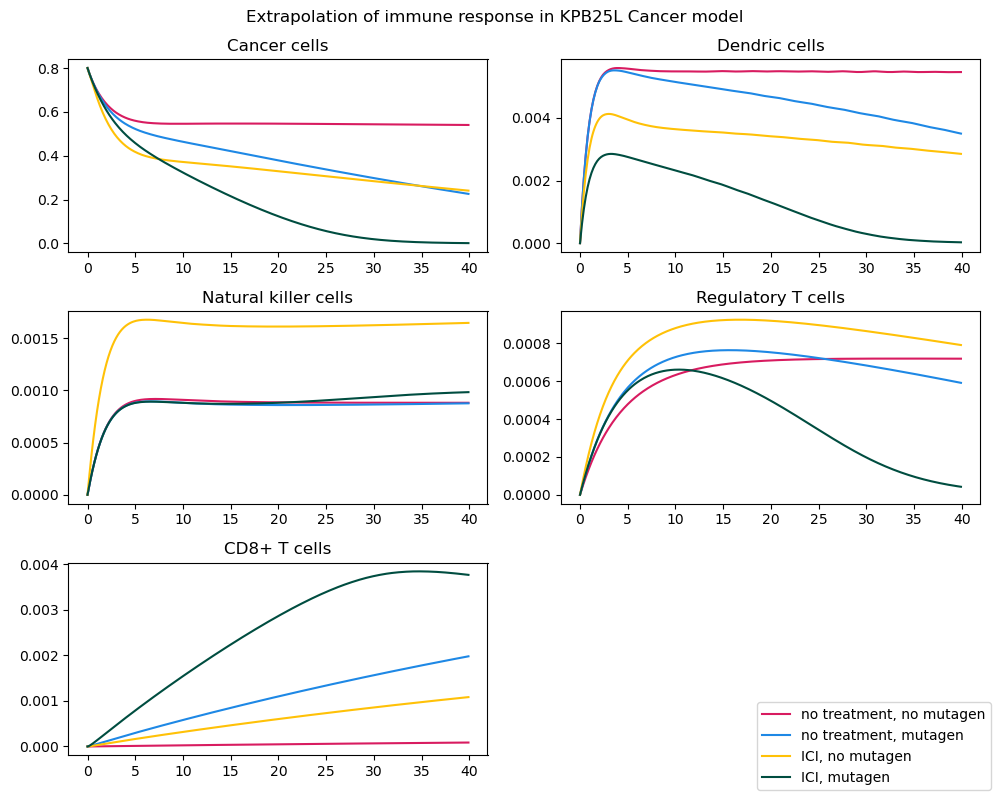

In [120]:

c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)

tspan = (0.0,40.0,)
C_init     = no_treatment_no_mutagen_best_params['C_init']
D_init     = no_treatment_no_mutagen_best_params['D_init']
N_init     = no_treatment_no_mutagen_best_params['N_init']
Tr_init    = no_treatment_no_mutagen_best_params['Tr_init']
T8_init    = no_treatment_no_mutagen_best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol_no_treatment_no_mutagen = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_treatment_no_mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,tspan[1],0.1,))
sol_no_treatment_mutagen = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_treatment_mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,tspan[1],0.1,))
sol_mutagen = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,tspan[1],0.1,))
sol_no_mutagen = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (no_mutagen_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,tspan[1],0.1,))

t_no_treatment_no_mutagen = sol_no_treatment_no_mutagen.t
y_no_treatment_no_mutagen = sol_no_treatment_no_mutagen.y
t_no_treatment_mutagen = sol_no_treatment_mutagen.t
y_no_treatment_mutagen = sol_no_treatment_mutagen.y
t_no_mutagen = sol_no_mutagen.t
y_no_mutagen = sol_no_mutagen.y
t_mutagen = sol_mutagen.t
y_mutagen = sol_mutagen.y


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t_no_treatment_no_mutagen,y_no_treatment_no_mutagen[0],color = c1,label = 'no treatment, no mutagen')
cancer.plot(t_no_treatment_mutagen,y_no_treatment_mutagen[0],color = c2,label = 'no treatment, mutagen')

cancer.plot(t_no_mutagen,y_no_mutagen[0],color = c3,label = 'ICI, no mutagen')
cancer.plot(t_mutagen,y_mutagen[0],color = c4,label = 'ICI, mutagen')
handles,labels = cancer.get_legend_handles_labels()

cancer.set_title('Cancer cells')
D_cells = ax[0,1]
D_cells.plot(t_no_treatment_no_mutagen,y_no_treatment_no_mutagen[1],color = c1)
D_cells.plot(t_no_treatment_mutagen,y_no_treatment_mutagen[1],color = c2)

D_cells.plot(t_no_mutagen,y_no_mutagen[1],color = c3)
D_cells.plot(t_mutagen,y_mutagen[1],color = c4)


D_cells.set_title('Dendric cells')


NK_cells = ax[1,0]
NK_cells.plot(t_no_treatment_no_mutagen,y_no_treatment_no_mutagen[2],color = c1)
NK_cells.plot(t_no_treatment_mutagen,y_no_treatment_mutagen[2],color = c2)
NK_cells.plot(t_no_mutagen,y_no_mutagen[2],color = c3)
NK_cells.plot(t_mutagen,y_mutagen[2],color = c4)

NK_cells.set_title('Natural killer cells')


Treg = ax[1,1]
Treg.plot(t_no_treatment_no_mutagen,y_no_treatment_no_mutagen[3],color = c1)
Treg.plot(t_no_treatment_mutagen,y_no_treatment_mutagen[3],color = c2)

Treg.plot(t_no_mutagen,y_no_mutagen[3],color = c3)
Treg.plot(t_mutagen,y_mutagen[3],color = c4)

Treg.set_title('Regulatory T cells')

T8 = ax[2,0]
T8.plot(t_no_treatment_no_mutagen,y_no_treatment_no_mutagen[4],color = c1)
T8.plot(t_no_treatment_mutagen,y_no_treatment_mutagen[4],color = c2)

T8.plot(t_no_mutagen,y_no_mutagen[4],color = c3)
T8.plot(t_mutagen,y_mutagen[4],color = c4)


T8.set_title('CD8+ T cells')


extra_plot = ax[2,1]
extra_plot.set_visible(False)
fig.legend(handles,labels,loc = 'lower right')
fig.suptitle("Extrapolation of immune response in KPB25L Cancer model")
plt.tight_layout()
plt.show()


In [59]:
# UV
objective_function_day3 = {'Ds':UV_Ds[0],
                          'NKs':UV_NKs[0],
                          'Tregs':UV_Tregs[0],
                          'T8s':UV_T8s[0]}
objective_function_day7 = {'Ds':UV_Ds[1],
                          'NKs':UV_NKs[1],
                          'Tregs':UV_Tregs[1],
                          'T8s':UV_T8s[1]}
params_to_change = {'lambda_T8_comb':[1e-5,5e-5,1e-4,7.5e-4,9e-4,1e-3,1.25e-3,1.5e-3,2e-3,1e-2,0.1,1.0,2.0,3.0,4.0,5.0],'lambda_DC_comb':[5e-4,7.5e-4,95e-4,1e-3,1.2e-3,1.25e-3,1.3e-3,1.4e-3,1.5e-3,2.0e-3],'sigma_N':[5e-5,7.5e-5,9e-5,1e-4,2e-4,2.5e-4,2.75e-4,3e-4,3.25e-4,3.5e-4,4e-4,5e-4,5e-3],'lambda_Tr_comb':[1e-4,2e-4,3e-4,5e-4,1e-3,5e-3]}
params = best_params

NameError: name 'UV_Ds' is not defined

In [85]:
import itertools

changed_params = {}
keys = params_to_change.keys()
values = params_to_change.values()
minimum_distance = 10000
prod = 1
for k in values:
    prod *= len(k)
iters = 0
print_points = np.arange(0,prod,prod//100,dtype = int)
for combo in itertools.product(*values):
    iters+=1
    if iters in print_points:
        print(f"iteration {iters} of {prod} i.e. {iters/prod*100}%")
    #update parameters
    for k,v in list(zip(keys,combo)):
        params[k] = v
        changed_params[k] = v
    lambda_C   = params['lambda_C']
    C_M        = params['C_M']
    eta_8      = params['eta_8']
    eta_N      = params['eta_N']
    d_C            = params['d_C']
    lambda_DC_comb = params['lambda_DC_comb']
    # D_0            = params['D_0']
    K_C        = params['K_C']
    d_D        = params['d_D']
    sigma_N    = params['sigma_N']
    d_N        = params['d_N']
    gamma_N    = params['gamma_N']
    a_C        = params['a_C']
    beta_1     = params['beta_1']
    beta_2     = params['beta_2']
    d_Tr       = params['d_Tr']
    lambda_Tr_comb  = params['lambda_Tr_comb']
    # Tr_0       = params['Tr_0']
    d_T8       = params['d_T8']
    lambda_T8_comb  = params['lambda_T8_comb']
    # T8_0       = params['T8_0']
    K_Tr       = params['K_Tr']
    K_D        = params['K_D']


    C_init     = params['C_init']
    D_init     = params['D_init']
    N_init     = params['N_init']
    Tr_init    = params['Tr_init']
    T8_init    = params['T8_init']

    C0 = [C_init,D_init,N_init,Tr_init,T8_init]
    tspan = (0.0,30.0,)
    
    
    #solve ivp
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (params,),rtol = 1e-6,abstol = 1e-10,t_eval = np.array([3.0,7.0]))
    
    if sol.success:
        distance = mean_square_error_rel(sol.y)
        if minimum_distance>distance:
            minimum_distance = distance
            UV_best_params = params.copy()
            print(distance)
            print({k:best_params[k] for k in params_to_change.keys()})
print(f'The minimum error is {minimum_distance}')
print({k:best_params[k] for k in params_to_change.keys()})

52.21815681176209
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 5e-05, 'lambda_Tr_comb': 0.0001}
52.09968212696052
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 7.5e-05, 'lambda_Tr_comb': 0.0001}
52.04326478952634
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 9e-05, 'lambda_Tr_comb': 0.0001}
52.00791325507639
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.0001, 'lambda_Tr_comb': 0.0001}
51.67800591529983
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.0002, 'lambda_Tr_comb': 0.0001}
51.5135791174925
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.00025, 'lambda_Tr_comb': 0.0001}
51.430341424634044
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.000275, 'lambda_Tr_comb': 0.0001}
51.34625340772184
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N': 0.0003, 'lambda_Tr_comb': 0.0001}
51.26126527030471
{'lambda_T8_comb': 1e-05, 'lambda_DC_comb': 0.0005, 'sigma_N

KeyboardInterrupt: 

In [93]:
print(UV_best_params['lambda_T8_comb'],UV_best_params['lambda_DC_comb'])
print(best_params['lambda_T8_comb'],best_params['lambda_DC_comb'])

0.002 0.0015
0.0001 0.0013


In [94]:
print(UV_best_params)
print(best_params)

{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0015, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 1e-05, 'lambda_T8_comb': 0.002, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
{'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0013, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.00035, 'd_N': 0.22, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0005, 'd_T8': 1e-05, 'lambda_T8_comb': 0.0001, 'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}


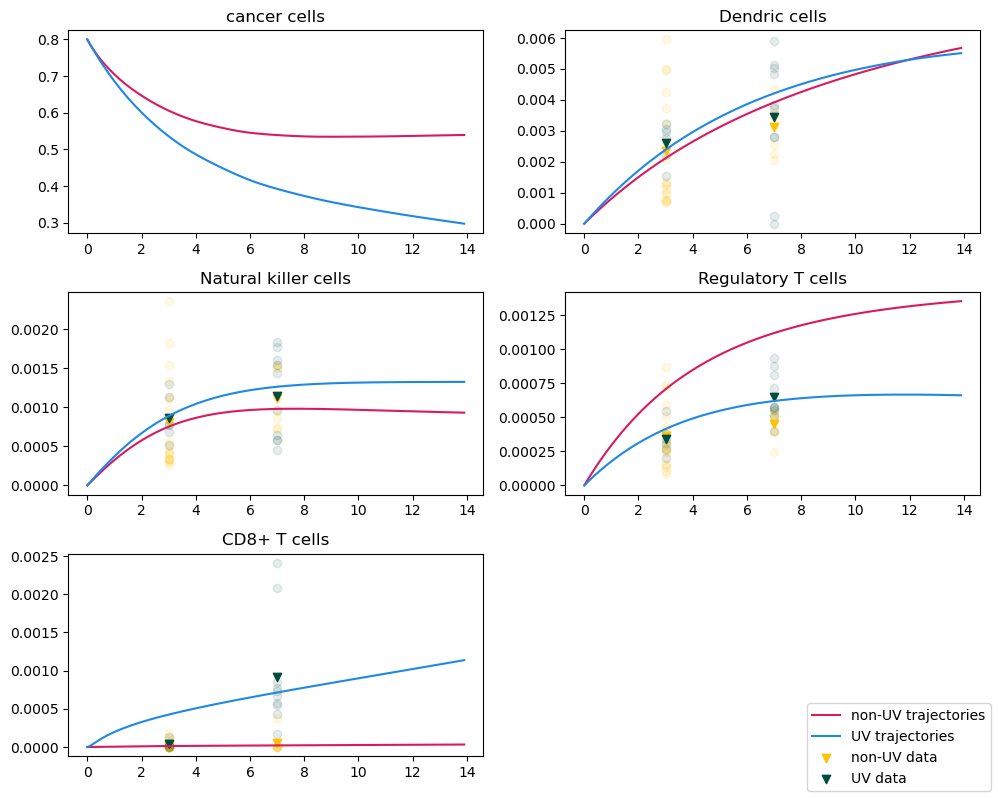

In [92]:
c1 = (216/255,27/255,96/255)
c2 = (30/255,136/255,229/255)
c3 = (255/255,193/255,7/255)
c4 = (0/255,77/255,64/255)


tspan = (0.0,14.0,)
C_init     = best_params['C_init']
D_init     = best_params['D_init']
N_init     = best_params['N_init']
Tr_init    = best_params['Tr_init']
T8_init    = best_params['T8_init']
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
sol = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
sol_UV = solve_ivp(cancer_ode_parametrised,tspan,C0,args = (UV_best_params,),abs_tol = 1e-9,t_eval = np.arange(0.0,14.0,0.1,))
t = sol.t
t_UV = sol_UV.t
y = sol.y
y_UV = sol_UV.y
import itertools

def cancer_ode_parametrised(t, y, p):
    return cancer_ode(
        t, y, 
        p['lambda_C'], p['C_M'], p['eta_8'], p['eta_N'], p['d_C'], 
        p['lambda_DC_comb'], p['K_C'], p['d_D'], p['sigma_N'], 
        p['d_N'], p['gamma_N'], p['a_C'], p['beta_1'], p['beta_2'], 
        p['d_Tr'], p['lambda_Tr_comb'], p['d_T8'], p['lambda_T8_comb'], 
        p['K_D'], p['K_Tr']
    )


fig,ax = plt.subplots(3,2,figsize = (10,8))
cancer = ax[0,0]
cancer.plot(t,y[0],color = c1)
cancer.plot(t,y_UV[0],color = c2)
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],color = c1,label = 'non-UV trajectories')
D_cells.plot(t_UV,y_UV[1],color = c2,label = 'UV trajectories')
D_cells.set_title('Dendric cells')
D_cells.scatter(scatter_times,scatter_Ds,alpha=0.1,color = c3)
D_cells.scatter(scatter_UV_times,scatter_UV_Ds,alpha=0.1,color = c4)
D_cells.scatter([3.0,7.0],Ds[:2],alpha=1.0,marker ='v',color = c3,label = 'non-UV data')
D_cells.scatter([3.0,7.0],UV_Ds[:2],alpha=1.0,marker ='v',color = c4,label = 'UV data')

handles = []
labels = []
handles,labels = D_cells.get_legend_handles_labels()
# for handle,label in D_cells.get_legend_handles_labels():
#     handles.append(handle)
#     labels.append(label)
    
NK_cells = ax[1,0]
NK_cells.plot(t,y[2],color = c1)
NK_cells.plot(t_UV,y_UV[2],color = c2)
NK_cells.set_title('Natural killer cells')
NK_cells.scatter(scatter_times,scatter_NKs,alpha=0.1,color = c3)
NK_cells.scatter(scatter_UV_times,scatter_UV_NKs,alpha=0.1,color = c4)
NK_cells.scatter([3,7],NKs[:2],alpha=1.0,marker ='v',color = c3)
NK_cells.scatter([3,7],UV_NKs[:2],alpha=1.0,marker ='v',color = c4)


Treg = ax[1,1]
Treg.plot(t,y[3],color = c1)
Treg.plot(t_UV,y_UV[3],color = c2)
Treg.set_title('Regulatory T cells')
Treg.scatter(scatter_times,scatter_Tregs,alpha=0.1,color = c3)
Treg.scatter(scatter_UV_times,scatter_UV_Tregs,alpha=0.1,color = c4)
Treg.scatter([3,7],Tregs[:2],alpha=1.0,marker ='v',color = c3)
Treg.scatter([3,7],UV_Tregs[:2],alpha=1.0,marker ='v',color = c4)

T8 = ax[2,0]
T8.plot(t,y[4],color = c1)
T8.plot(t_UV,y_UV[4],color = c2)
T8.set_title('CD8+ T cells')
T8.scatter(scatter_times,scatter_T8s,alpha=0.1,color = c3)
T8.scatter(scatter_UV_times,scatter_UV_T8s,alpha=0.1,color = c4)
T8.scatter([3,7],T8s[:2],alpha=1.0,marker ='v',color = c3)
T8.scatter([3,7],UV_T8s[:2],alpha=1.0,marker ='v',color = c4)


extra_plot = ax[2,1]
extra_plot.set_visible(False)

fig.legend(handles,labels,loc = 'lower right')

plt.tight_layout()
plt.show()

In [12]:
C0 = [C_init,D_init,N_init,Tr_init,T8_init]
# C0 = [0.8,0.0,0.0,0.00,0.0]

tspan = (0.0,50.0,)
import time

In [13]:
sol = solve_ivp(cancer_ode_parametrised,tspan,C0)

TypeError: cancer_ode_parametrised() missing 1 required positional argument: 'p'

In [53]:
from matplotlib import pyplot as plt

NameError: name 'scatter_times' is not defined

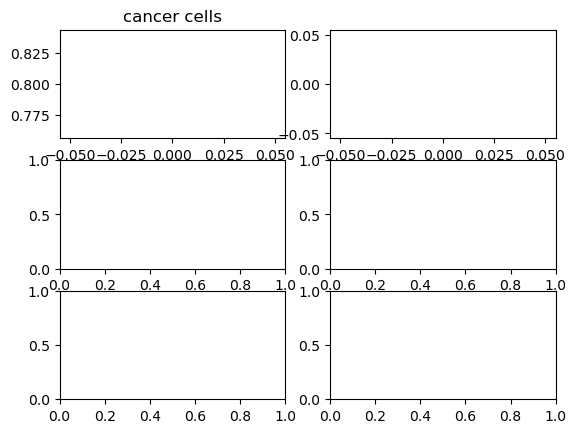

In [108]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1],'b')
D_cells.scatter(scatter_times,scatter_Ds,'r')
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param = params
def cancer_ode_parametrised(t,y):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)

In [ ]:
param_grid = {
    'eta_8':[328.25]
    'eta_N':[300]
    'D0':[],
    'NK0':[],
    'Treg0':[],
    'T80':[0.0]
}

In [8]:
# parameters we are varying
y_data = np.array(
for param in param_grid:
    sigma_N,lambda_Tr,Tr_0,lambda_T8,T8_0,K_D,K_Tr=parm0 
    def cancer_ode_parametrised(t,y):
        return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
                   D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
                   beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
                  T8_0,K_D,K_Tr)
    tspan = (0.0,200.0,)
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0)

(5, 10)


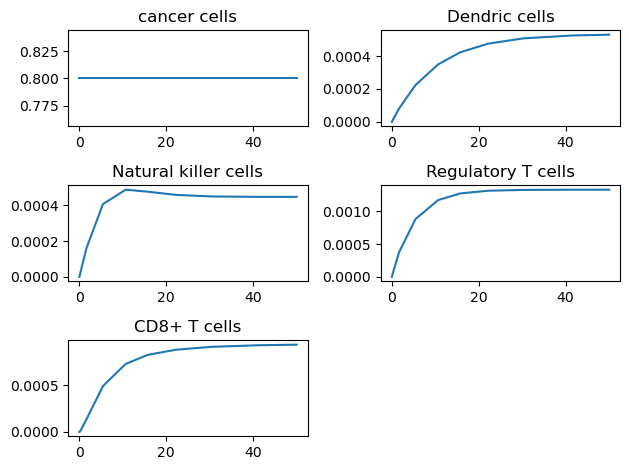

In [106]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [94]:
# SDEs
import sdeint
from sdeint import itoint
from sdeint import itoEuler

# need a noise term
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.0,0.2]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param,noise_NK_prod = params
def cancer_ode_parametrised(y,t):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,(1-noise_NK_prod)*sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)
def G(y,t):
    C,D,N,Tr,T8 = y
    return np.diag((noise_param*lambda_C*C*(1-C/C_M),0,noise_NK_prod*sigma_N,0,0,))

In [95]:
t = np.arange(tspan[0],tspan[1],0.001)
sol = itoEuler(cancer_ode_parametrised, G, C0, t)

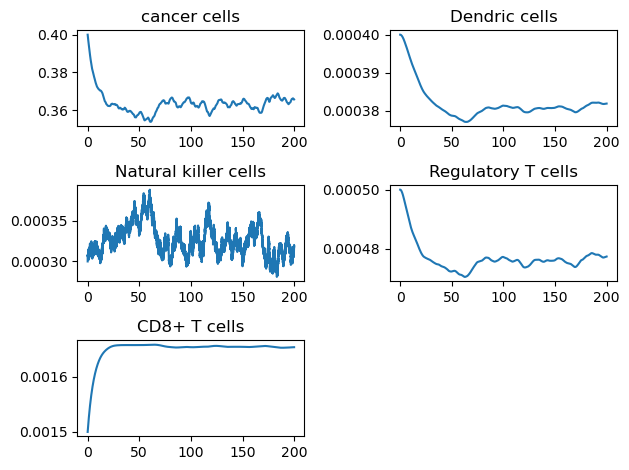

In [96]:
y = []
i = 0
for i in range(sol.shape[1]):
    y.append(sol[:,i])
fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()
